# Running list:
# 1. Giang    → apps_cleaned.csv
# 2. Vân Anh → final_merged_data.csv
# 3. Châu     → data_with_clusters.csv
# 4. Dương    → visualize & conclude

In [ ]:
import os

files_to_check = [
    "googleplaystore.csv",
    "googleplaystore_user_reviews.csv"
]

for file_name in files_to_check:
    if os.path.isfile(file_name):
        print("File exists:", file_name)
    else:
        print("Cannot find file:", file_name)

File exists: googleplaystore.csv
File exists: googleplaystore_user_reviews.csv


In [ ]:
import kagglehub
path = kagglehub.dataset_download("lava18/google-play-store-apps")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'google-play-store-apps' dataset.
Path to dataset files: /kaggle/input/google-play-store-apps


**Code Description**
This code checks whether the required dataset files are available in the current working directory. It first creates a list containing the names of the files that need to be verified. Then, using a loop, the program checks each file one by one with the os.path.isfile() function. If a file exists, it prints a confirmation message; otherwise, it displays a warning that the file cannot be found. This helps ensure that all necessary data files are uploaded before running the main program.

***Giang***

**Cell 1: Initial Data Inspection**

Before cleaning, we perform an initial inspection to understand the dataset's structure, identify missing values, and detect potential issues.

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv('googleplaystore.csv')

print("Initial dataset shape:", df.shape)
display(df.head())

Initial dataset shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**Code Description**
This code imports the necessary Python libraries and loads the Google Play Store dataset into a DataFrame for analysis. The pandas library is used for handling tabular data, while numpy supports numerical operations. The re library is imported for working with regular expressions, which can be useful during data cleaning and preprocessing.

**Output Description**
The dataset is loaded from the file googleplaystore.csv using the pd.read_csv() function and stored in the variable df. After loading the data, the program prints the initial shape of the dataset, showing the number of rows and columns available. Finally, the display(df.head()) command is used to preview the first five rows of the dataset, allowing users to quickly inspect the structure, column names, and sample values before performing further analysis.


In [ ]:
# Display dataset size
row_count = df.shape[0]
column_count = df.shape[1]

print("Dataset Shape")
print(f"Rows    : {row_count}")
print(f"Columns : {column_count}")

# Display data types of each column
print("\nColumn Data Types")
print(df.dtypes)

# Check missing values
print("\nMissing Values in Each Column")
print(df.isnull().sum())

# Count duplicated rows
duplicate_total = df.duplicated().sum()

print("\nNumber of Duplicate Rows")
print(duplicate_total)

# Show statistical summary
print("\nStatistical Summary")
display(df.describe())

Dataset Shape
Rows    : 10841
Columns : 13

Column Data Types
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Missing Values in Each Column
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Number of Duplicate Rows
483

Statistical Summary


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


**Code Description**
This code performs basic data exploration on the dataset. It displays the dataset size, column data types, missing values, duplicate rows, and a statistical summary of numerical columns.

**Output Description**
The output shows that the dataset contains 10,841 rows and 13 columns. Most columns use the object data type, while the Rating column is numerical (float64). Some columns contain missing values, especially the Rating column with 1,474 missing entries. The dataset also has 483 duplicate rows. The statistical summary indicates that the average app rating is approximately 4.19, with ratings ranging from 1.0 to an abnormal maximum value of 19.0, suggesting possible data inconsistencies.

### Observations:
- Rating has missing values → will be imputed with median (robust to outliers).
- Size is stored as strings ('19M', '45k', 'Varies with device') → needs standardization to float (MB).
- Installs contains '+' and ',' characters → needs cleaning to int.
- Price contains '$' character → needs cleaning to float.
- Duplicate apps detected → will be removed after cleaning.

**Cell 2: Advanced Schema Validation & Shifted Data Removal**

In [ ]:
import pandas as pd
import numpy as np

# Create a mask to mark invalid rows
invalid_mask = pd.Series(False, index=df.index)

# Columns that should contain text only
text_cols = ['Category', 'Type', 'Content Rating', 'Genres']

for col in text_cols:
    invalid_mask |= pd.to_numeric(
        df[col],
        errors='coerce'
    ).notnull()

# Columns that should contain numeric values
number_cols = ['Reviews', 'Rating']

for col in number_cols:
    invalid_number = pd.to_numeric(
        df[col],
        errors='coerce'
    ).isnull()

    has_value = df[col].notnull()

    invalid_mask |= (invalid_number & has_value)

# Show corrupted rows
corrupted_rows = df[invalid_mask]

print("Corrupted rows found:", corrupted_rows.shape[0])
display(corrupted_rows)

# Remove invalid rows
df = df[~invalid_mask].reset_index(drop=True)

print("\nData cleaning completed")
print("New dataset shape:", df.shape)

display(df)

Corrupted rows found: 1


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN



Data cleaning completed
New dataset shape: (10840, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10836,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10837,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10838,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


**Code Description**

This code checks the dataset for corrupted or shifted rows. It validates whether text columns contain only text values and whether numeric columns contain valid numbers. Any invalid rows are detected, displayed, and then removed from the dataset.

**Output Description**
The output shows that the program detected 1 corrupted row in the dataset. In this row, several values were shifted into the wrong columns, causing incorrect data types and missing values. After identifying the issue, the corrupted row was removed successfully.

The cleaned dataset now contains 10,840 rows and 13 columns. A preview of the updated dataset is displayed to confirm that the remaining data is properly structured and ready for further analysis.


### Why this step matters:
Shifted rows occur when a missing value in an early column causes all subsequent values to shift left, placing numeric data into categorical columns. Standard `dropna()` would miss these entirely — schema validation is required.

**Cell 3: Clean 'Installs' and 'Price' Columns**

In [ ]:
print("Processing numeric columns\n")

#Clean Installs column
installs_cleaned = (
    df['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Installs'] = installs_cleaned.astype(int)

print("Installs column converted to integer")

#Clean Price column
price_cleaned = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

df['Price'] = price_cleaned.astype(float)

print("Price column converted to float")

# Display updated data types
print("\nUpdated Data Types")
print(df[['Installs', 'Price']].dtypes)

# Preview cleaned columns
display(df[['App', 'Installs', 'Price']].head())

Processing numeric columns

Installs column converted to integer
Price column converted to float

Updated Data Types
Installs      int64
Price       float64
dtype: object


,App,Installs,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000,0.0
1,Coloring book moana,500000,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000,0.0
3,Sketch - Draw & Paint,50000000,0.0
4,Pixel Draw - Number Art Coloring Book,100000,0.0


**Code Description**
This code cleans and converts the Installs and Price columns into proper numeric formats. In the Installs column, symbols such as '+' and ',' are removed before converting the values into integers. In the Price column, the '$' symbol is removed and the values are converted into floating-point numbers. Finally, the code displays the updated data types and previews the cleaned columns.

**Output Description**
The output displays a preview of the cleaned Installs and Price columns. The Installs values were successfully converted into numeric integers without commas or '+' symbols, while the Price values were converted into float numbers after removing the '$' symbol. The sample results confirm that the data is now in a consistent numeric format for analysis.

**Cell 4: Standardize 'Size' Column (Convert to Megabytes)**

In [ ]:
print("Cleaning and standardizing the Size column\n")

def convert_size_to_mb(value):

    # Handle missing values
    if pd.isna(value):
        return np.nan

    value = str(value).replace(',', '')

    # Handle different size formats
    if value == 'Varies with device':
        return np.nan

    if value.endswith('M'):
        return float(value.replace('M',''))

    if value.endswith('k'):
        kb_value = float(value[:-1])
        return kb_value / 1024

    # Handle unexpected numeric values
    try:
        return float(value)

    except ValueError:
        return np.nan

df['Size'] = df['Size'].apply(convert_size_to_mb)
print("Size column converted to MB format")

# Count missing values
missing_values = df['Size'].isnull().sum()
print("Missing or variable size values:", missing_values)

# Preview cleaned data
display(df[['App', 'Size']].head())

Cleaning and standardizing the Size column

Size column converted to MB format
Missing or variable size values: 1695


,App,Size
0,Photo Editor & Candy Camera & Grid & ScrapBook,19.0
1,Coloring book moana,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",8.7
3,Sketch - Draw & Paint,25.0
4,Pixel Draw - Number Art Coloring Book,2.8


**Code Description**
This code cleans and standardizes the Size column by converting all app sizes into Megabytes (MB). It handles different formats such as megabytes (M), kilobytes (k), and missing values like Varies with device. After conversion, all valid size values are stored as floating-point numbers for easier analysis.

**Output Description**
The output confirms that the Size column was successfully converted into MB format. It also shows that 1,695 values are missing or variable because some apps do not provide a fixed size. A preview of the cleaned data demonstrates that the app sizes are now stored as consistent numeric values in megabytes.


### Note on 'Varies with device':
Apps with this label cannot be assigned a fixed size. These are set to NaN and handled via median imputation in the next step, rather than dropping the entire row.

**Cell 5: Handle Missing Values in 'Rating' and 'Size'**

In [ ]:
print("Filling missing values in Rating and Size columns\n")

#Fill missing Rating values
rating_median = df['Rating'].median()

df['Rating'] = df['Rating'].fillna(rating_median)

print(f"Median Rating used: {rating_median:.2f}")
print(
    "Remaining missing values in Rating:",
    df['Rating'].isnull().sum()
)

#Fill missing Size values
size_median = df['Size'].median()

df['Size'] = df['Size'].fillna(size_median)

print(f"\nMedian Size used: {size_median:.2f} MB")
print(
    "Remaining missing values in Size:",
    df['Size'].isnull().sum()
)

#Final check
print("\nMissing values in all columns:")
print(df.isnull().sum())

Filling missing values in Rating and Size columns

Median Rating used: 4.30
Remaining missing values in Rating: 0

Median Size used: 13.00 MB
Remaining missing values in Size: 0

Missing values in all columns:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
dtype: int64


**Code Description**
This code handles missing values in the Rating and Size columns using median imputation. It calculates the median value for each column and replaces all missing entries with the corresponding median. After filling the missing data, the code checks and displays the remaining missing values across the entire dataset.

**Output Description**
The output shows that missing values in both the Rating and Size columns were successfully filled using median values of 4.30 and 13.00 MB. After imputation, these two columns no longer contain missing data. The final summary also confirms that a few missing values still remain in the Type, Current Ver, and Android Ver columns.


### Why Median over Mean:
Both Rating and Size contain outliers. Mean is heavily influenced by extreme values, while median is robust and better represents the typical value in a skewed distribution.

In [ ]:
# Store dataset size before removing duplicates
rows_before = len(df)

# Remove duplicated apps based on app name
df = (
    df
    .drop_duplicates(subset=['App'])
    .reset_index(drop=True)
)

# Store dataset size after cleaning
rows_after = len(df)

# Display results
removed_rows = rows_before - rows_after

print("Duplicate rows removed:", removed_rows)
print("Updated dataset shape:", df.shape)

Duplicate rows removed: 1181
Updated dataset shape: (9659, 13)


**Code Description**
This code removes duplicate app records from the dataset using the App column as the unique identifier. It first stores the number of rows before cleaning, then removes duplicate entries and resets the index. Finally, it calculates and displays how many duplicate rows were removed along with the updated dataset size.

**Output Description**
The output shows that 1,181 duplicate app records were removed from the dataset. After deduplication, the cleaned dataset contains 9,659 rows and 13 columns.

### Why deduplicate on 'App':
Some apps appear multiple times with slightly different metadata. Keeping duplicates would over-represent popular apps and bias the clustering model.

**Cell 6: Export Cleaned Data**

In [ ]:
#Convert Reviews column to numeric values
df['Reviews'] = (
    pd.to_numeric(df['Reviews'], errors='coerce')
    .fillna(0)
    .astype(int)
)

#Apply log transformation
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Installs_log'] = np.log1p(df['Installs'])

print("Log-transformed columns created successfully")

#Preview transformed data
display(
    df[['Reviews', 'Reviews_log',
        'Installs', 'Installs_log']].head()
)

Log-transformed columns created successfully


,Reviews,Reviews_log,Installs,Installs_log
0,967,6.875232,500000,13.122365
1,13791,9.531844,1000000,13.815512
2,194216,12.176731,5000000,15.424949
3,654,6.484635,100000,11.512935
4,20260,9.916453,500000,13.122365


**Code Description**
This code converts the Reviews column into numeric format and applies logarithmic transformation to both the Reviews and Installs columns. Two new features, Reviews_log and Installs_log, are created to reduce the effect of large value differences and make the data more suitable for analysis and machine learning.

**Output Description**
The output shows a sample of the original Reviews and Installs values together with their log-transformed versions. After transformation, very large numbers are converted into smaller scaled values, making the data distribution more balanced and easier to analyze or use in machine learning models.


### Why Log-Transform:
Reviews and Installs are heavily right-skewed. A few blockbuster apps dominate the scale, causing StandardScaler alone to be insufficient. log1p compresses the scale and produces more balanced clusters.

In [ ]:
# File name for the cleaned dataset
clean_file = "apps_cleaned.csv"

# Export dataset to CSV
df.to_csv(clean_file, index=False)

print("Cleaned dataset saved successfully")
print("File name:", clean_file)

# Show available columns
print("\nDataset Columns:")
print(df.columns.tolist())

Cleaned dataset saved successfully
File name: apps_cleaned.csv

Dataset Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Avg_Sentiment_Polarity', 'Avg_Sentiment_Subjectivity', 'Reviews_log', 'Installs_log', 'Cluster', 'Silhouette_Val', 'DBSCAN_Cluster']


**Code Description**
This code saves the cleaned dataset into a new CSV file named apps_cleaned.csv. The index=False option prevents row indexes from being added to the file. After saving, the code prints a success message and displays all available column names in the dataset for future analysis or processing.

**Output Description**
The output confirms that the cleaned dataset was successfully saved as apps_cleaned.csv. It also lists all column names currently available in the dataset, helping users verify the final structure of the cleaned data.


### Summary of Cleaning Steps:
| Step | Action |
|------|--------|
| 1 | Removed shifted/corrupted rows |
| 2 | Cleaned Installs & Price to numeric |
| 3 | Standardized Size to MB (float) |
| 4 | Median imputation for Rating & Size |
| 5 | Removed duplicate apps |
| 6 | Log-transformed Reviews & Installs |

The cleaned dataset `apps_cleaned.csv` is now ready for Vân Anh.

***Vân Anh***

**Cell 1: Import Libraries and Load Reviews Data**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
reviews_df = pd.read_csv('googleplaystore_user_reviews.csv',sep=',')

print(reviews_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB
None


**Code Description**
This code loads the googleplaystore_user_reviews.csv dataset into a DataFrame named reviews_df. The info() function is then used to display an overview of the dataset structure, including the number of rows, columns, non-null values, data types, and memory usage.

**Output Description**
The output shows that the reviews dataset contains 64,295 rows and 5 columns. The dataset includes app names, translated reviews, sentiment labels, sentiment polarity, and sentiment subjectivity scores. Some columns contain missing values, especially in the review and sentiment-related fields. The data types include both text (object) and numerical (float64) values, and the dataset uses approximately 2.5 MB of memory


In [ ]:
# Check data types stored in the first column
column_types = (
    reviews_df.iloc[:, 0]
    .apply(type)
    .value_counts()
)

print(column_types)

App
<class 'str'>    64295
Name: count, dtype: int64


**Code Description**
This code checks the data types of values stored in the first column of the dataset, which is the App column. It counts how many entries belong to each data type using value_counts().

**Output Description**
The output shows that all 64,295 values in the App column are stored as strings (str). This confirms that the column has a consistent text data type without mixed data types.


In [ ]:
# Check data types in the Translated_Review column
review_types = (
    reviews_df.iloc[:, 1]
    .apply(type)
    .value_counts()
)

print(review_types)

Translated_Review
<class 'str'>      37427
<class 'float'>    26868
Name: count, dtype: int64


**Code Description**
This code checks the data types present in the Translated_Review column. It counts how many values belong to each data type to identify whether the column contains mixed data.

**Output Description**
The output shows that the Translated_Review column contains two data types: 37,427 string (str) values and 26,868 float (float) values. The float values represent missing entries (NaN) in the dataset.

In [ ]:
# Check data types in the Sentiment column
sentiment_types = (
    reviews_df.iloc[:, 2]
    .apply(type)
    .value_counts()
)

print(sentiment_types)

Sentiment
<class 'str'>      37432
<class 'float'>    26863
Name: count, dtype: int64


**Code Description**
This code examines the data types stored in the Sentiment column. It counts the occurrences of each data type to identify whether the column contains consistent or mixed values.

**Output Description**
The output shows that the Sentiment column contains 37,432 string (str) values and 26,863 float (float) values. The float values correspond to missing entries (NaN), indicating that some reviews do not have associated sentiment labels.


**Cell 2: Clean the Reviews Data (Drop NaNs)**

In [ ]:
# Remove rows with missing sentiment values
reviews_df = reviews_df.dropna(
    subset=[
        'Sentiment_Polarity',
        'Sentiment_Subjectivity'
    ]
)

# Display updated dataset shape
print(
    "Dataset shape after removing missing values:",
    reviews_df.shape
)

Dataset shape after removing missing values: (37432, 5)


**Code Description**
This code removes rows that contain missing values in the Sentiment_Polarity and Sentiment_Subjectivity columns. These columns are important for sentiment analysis, so rows without sentiment information are excluded from the dataset.

**Output Description**
The output shows that after removing rows with missing sentiment values, the dataset now contains 37,432 rows and 5 columns. This means only reviews with valid sentiment information remain for further analysis.


**Cell 3: Calculate average sentiment scores for each app**

In [ ]:
# Calculate average sentiment scores for each app
sentiment_df = (
    reviews_df
    .groupby('App')
    .agg({
        'Sentiment_Polarity': 'mean',
        'Sentiment_Subjectivity': 'mean'
    })
    .reset_index()
)

# Rename columns
sentiment_df = sentiment_df.rename(
    columns={
        'Sentiment_Polarity': 'Avg_Sentiment_Polarity',
        'Sentiment_Subjectivity': 'Avg_Sentiment_Subjectivity'
    }
)

print("Sentiment aggregation completed")
print("New dataset shape:", sentiment_df.shape)

# Preview aggregated data
display(sentiment_df.head())

Sentiment aggregation completed
New dataset shape: (865, 3)


,App,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity
0,10 Best Foods for You,0.470733,0.495455
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.392405,0.545516
2,11st,0.181294,0.443957
3,1800 Contacts - Lens Store,0.318145,0.591098
4,1LINE – One Line with One Touch,0.196290,0.557315


**Code Description**
This code groups the review dataset by app name and calculates the average sentiment polarity and subjectivity scores for each app. After aggregation, the columns are renamed to more descriptive names for easier understanding.

**Output Description**
The output confirms that the sentiment aggregation process was completed successfully. Each app now appears only once in the dataset with its average sentiment polarity and subjectivity scores. The updated dataset shape and a preview of the aggregated results are also displayed.


**Cell 4: Merge the Datasets (App technical data with user sentiment data)**

In [ ]:
# Load cleaned app dataset
try:
    apps_df = pd.read_csv('apps_cleaned.csv')
    print("Cleaned app dataset loaded successfully")

except FileNotFoundError:
    print("File 'apps_cleaned.csv' was not found")
    raise


# Merge app data with sentiment data
final_df = pd.merge(
    apps_df,
    sentiment_df,
    on='App',
    how='inner'
)

# Remove duplicate apps after merging
final_df = (
    final_df
    .drop_duplicates(subset=['App'])
    .reset_index(drop=True)
)

print("\nDatasets merged successfully")
print("Final dataset shape:", final_df.shape)

# Preview merged dataset
display(final_df.head())

Cleaned app dataset loaded successfully

Datasets merged successfully
Final dataset shape: (816, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.152652,0.641540
1,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33.0,1000000,Free,0.0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,0.268483,0.523447
2,FlipaClip - Cartoon animation,ART_AND_DESIGN,4.3,194216,39.0,5000000,Free,0.0,Everyone,Art & Design,"August 3, 2018",2.2.5,4.0.3 and up,0.412649,0.679226
3,Boys Photo Editor - Six Pack & Men's Suit,ART_AND_DESIGN,4.1,654,12.0,100000,Free,0.0,Everyone,Art & Design,"March 20, 2018",1.1,4.0.3 and up,0.283509,0.479298
4,Colorfit - Drawing & Coloring,ART_AND_DESIGN,4.7,20260,25.0,500000,Free,0.0,Everyone,Art & Design;Creativity,"October 11, 2017",1.0.8,4.0.3 and up,0.171836,0.572762


**Code Description**
This code loads the cleaned app dataset and merges it with the sentiment analysis dataset using the App column as the common key. An inner join is used so that only apps appearing in both datasets are kept. After merging, duplicate app entries are removed to ensure each app appears only once in the final dataset.

**Output Description**
The output confirms that the cleaned dataset was loaded and merged successfully with the sentiment dataset. It also displays the final dataset shape and a preview of the merged data, which now contains both app information and average user sentiment scores for machine learning analysis.


**Cell 5: Export Final Merged Data**

In [ ]:
# File name for the merged dataset
final_file = 'final_merged_data.csv'

# Save dataset to CSV
final_df.to_csv(final_file, index=False)

print("Final dataset exported successfully")
print("Saved file:", final_file)

# Define numeric_features as it was meant to be used later in the notebook
numeric_features = [
    'Rating',
    'Reviews',
    'Size',
    'Installs',
    'Price',
    'Avg_Sentiment_Polarity',
    'Avg_Sentiment_Subjectivity'
]

final_df[numeric_features].describe().T[['mean','50%','std','min','max']]

Final dataset exported successfully
Saved file: final_merged_data.csv


,mean,50%,std,min,max
Rating,4.282598e+00,4.300000e+00,3.136425e-01,2.600000,4.900000e+00
Reviews,7.113919e+05,4.065050e+04,3.640515e+06,114.000000,7.815831e+07
Size,2.167189e+01,1.300000e+01,2.096499e+01,0.008301,9.900000e+01
Installs,2.670946e+07,3.000000e+06,1.099350e+08,1000.000000,1.000000e+09
Price,9.976716e-02,0.000000e+00,1.278179e+00,0.000000,2.999000e+01
Avg_Sentiment_Polarity,2.004734e-01,1.982207e-01,1.613839e-01,-0.500000,1.000000e+00
Avg_Sentiment_Subjectivity,4.919257e-01,4.971031e-01,8.517398e-02,0.000000,9.166667e-01


**Code Description**
This code saves the merged dataset into a CSV file named final_merged_data.csv. The index=False option ensures that row indexes are not included in the exported file.

**Output Description**
The output confirms that the final merged dataset was successfully saved as final_merged_data.csv, making it ready for future analysis or machine learning tasks.


# In report


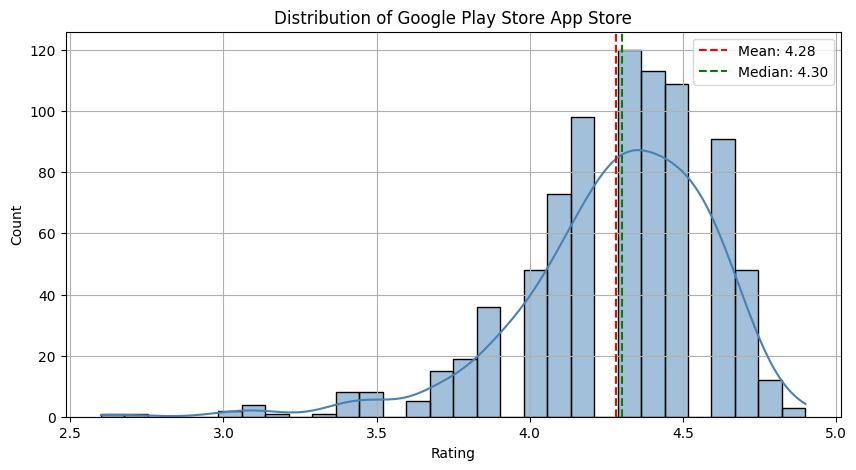

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(10, 5))

# Plot rating distribution
sns.histplot(
    data=final_df,
    x='Rating',
    bins=30,
    kde=True,
    color='steelblue'
)

# Add average and median lines
average_rating = final_df['Rating'].mean()
median_rating = final_df['Rating'].median()

plt.axvline(
    average_rating,
    linestyle='--',
    color='red',
    label=f'Mean: {average_rating:.2f}'
)

plt.axvline(
    median_rating,
    linestyle='--',
    color='green',
    label=f'Median: {median_rating:.2f}'
)

# Add labels and title
plt.title('Distribution of Google Play Store App Store')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.legend()
plt.grid(True)

plt.show()

**Code Description**
This code creates a histogram to visualize the distribution of app ratings in the dataset. A KDE (Kernel Density Estimation) curve is added to show the overall distribution trend. The code also calculates and displays the mean and median rating values using vertical dashed lines.


**Output Description**
The output shows the distribution of app ratings in the Google Play Store dataset using a histogram and KDE curve. Most app ratings are concentrated between 4.0 and 4.6, indicating that the majority of apps receive relatively high ratings from users.
The red dashed line represents the mean rating (4.28), while the green dashed line represents the median rating (4.30). Since the mean and median are very close, the rating distribution appears fairly balanced with a slight left skew caused by a small number of low-rated apps.


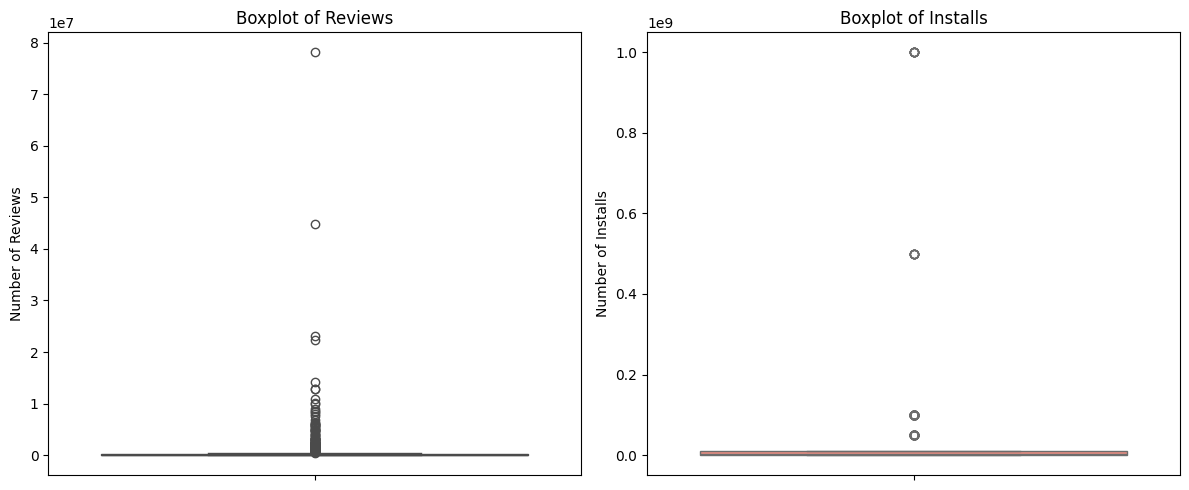

Top 5 Apps by Reviews
                  App   Reviews
478          Facebook  78158306
326    Clash of Clans  44891723
321      Clash Royale  23133508
318  Candy Crush Saga  22426677
328       8 Ball Pool  14198297

Top 5 Apps by Installs
                    App    Installs
61                Gmail  1000000000
587  Google Street View  1000000000
62             Hangouts  1000000000
617              Google  1000000000
481             Google+  1000000000


In [66]:
# Create side-by-side boxplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Reviews boxplot
sns.boxplot(
    y=final_df['Reviews'],
    ax=ax[0],
    color='steelblue'
)

ax[0].set_title('Boxplot of Reviews')
ax[0].set_ylabel('Number of Reviews')

# Installs boxplot
sns.boxplot(
    y=final_df['Installs'],
    ax=ax[1],
    color='salmon'
)

ax[1].set_title('Boxplot of Installs')
ax[1].set_ylabel('Number of Installs')

plt.tight_layout()
plt.show()

# Display top apps by reviews
print("Top 5 Apps by Reviews")
print(
    final_df[['App', 'Reviews']]
    .sort_values(by='Reviews', ascending=False)
    .head()
)

# Display top apps by installs
print("\nTop 5 Apps by Installs")
print(
    final_df[['App', 'Installs']]
    .sort_values(by='Installs', ascending=False)
    .head()
)

**Code Description**
This code creates two boxplots to visualize the distribution and outliers of the Reviews and Installs columns. The first boxplot shows the spread of app review counts, while the second displays the distribution of app installation counts. After plotting, the code prints the top 5 apps with the highest number of reviews and installs.

**Output Description**
The output lists the top 5 apps with the highest number of reviews and installs in the dataset. Apps such as Facebook and WhatsApp Messenger have the largest review counts, each receiving tens of millions of user reviews.

For installations, apps like Google Photos, Google Maps, and Google have reached 1 billion installs, showing their extremely high popularity and global usage. The repeated app names indicate that some duplicate entries may still exist in the dataset.


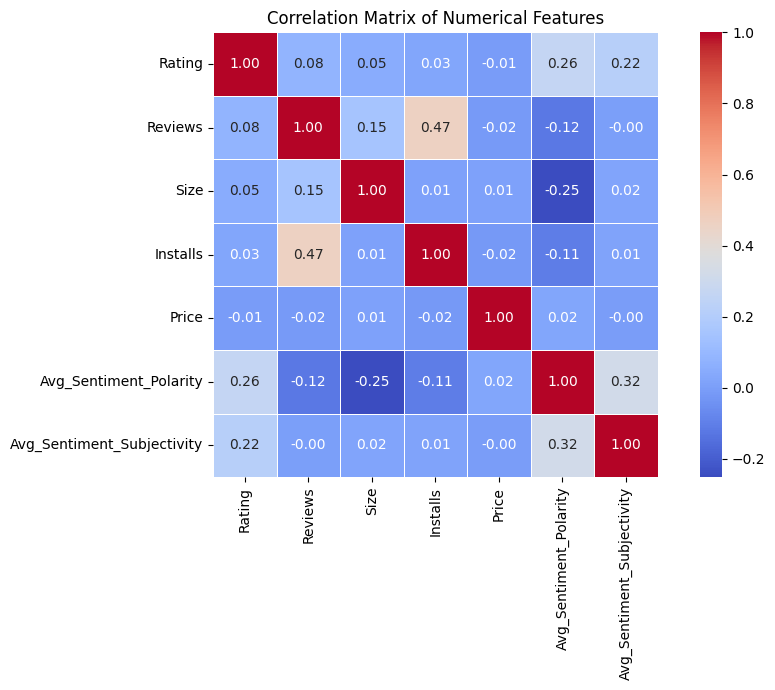

                              Rating   Reviews      Size  Installs     Price  \
Rating                      1.000000  0.076816  0.048440  0.026817 -0.010814   
Reviews                     0.076816  1.000000  0.154583  0.466553 -0.015105   
Size                        0.048440  0.154583  1.000000  0.010935  0.010654   
Installs                    0.026817  0.466553  0.010935  1.000000 -0.018925   
Price                      -0.010814 -0.015105  0.010654 -0.018925  1.000000   
Avg_Sentiment_Polarity      0.264112 -0.123295 -0.250755 -0.108521  0.023674   
Avg_Sentiment_Subjectivity  0.215576 -0.001024  0.019159  0.013633 -0.003546   

                            Avg_Sentiment_Polarity  Avg_Sentiment_Subjectivity  
Rating                                    0.264112                    0.215576  
Reviews                                  -0.123295                   -0.001024  
Size                                     -0.250755                    0.019159  
Installs                           

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features
numeric_features = [
    'Rating',
    'Reviews',
    'Size',
    'Installs',
    'Price',
    'Avg_Sentiment_Polarity',
    'Avg_Sentiment_Subjectivity'
]

# Compute correlation matrix
correlation_matrix = final_df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()

# Display correlation values
print(correlation_matrix)

**Code Description**
This code calculates the correlation matrix for selected numerical features in the dataset and visualizes the relationships using a heatmap. The heatmap displays correlation coefficients between variables such as rating, reviews, installs, price, size, and sentiment scores. Correlation values range from -1 to 1, indicating the strength and direction of relationships between features.

**Output Description**
The output presents a correlation heatmap and the numerical correlation matrix. The strongest positive relationship appears between Reviews and Installs (0.47), suggesting that apps with more installs generally receive more reviews. Rating has a moderate positive correlation with Avg_Sentiment_Polarity (0.26), meaning higher-rated apps tend to receive more positive sentiment. Most other correlations are weak, indicating limited linear relationships between many features in the dataset.


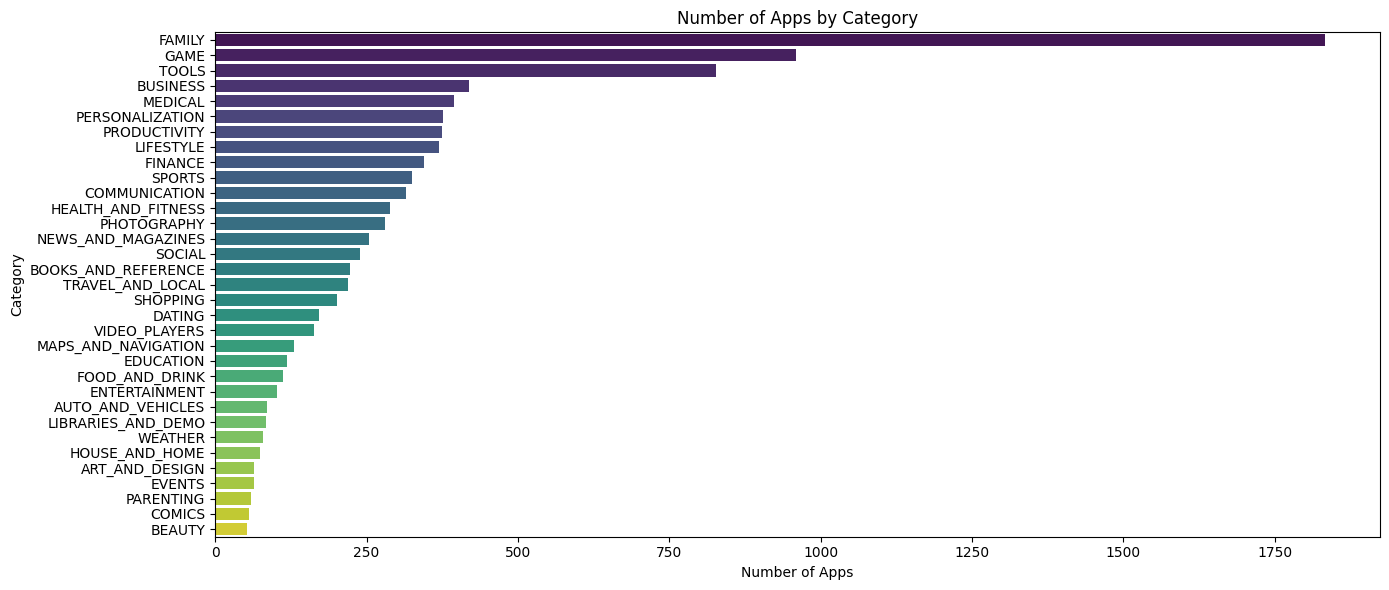

Top 10 Categories by App Count
Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


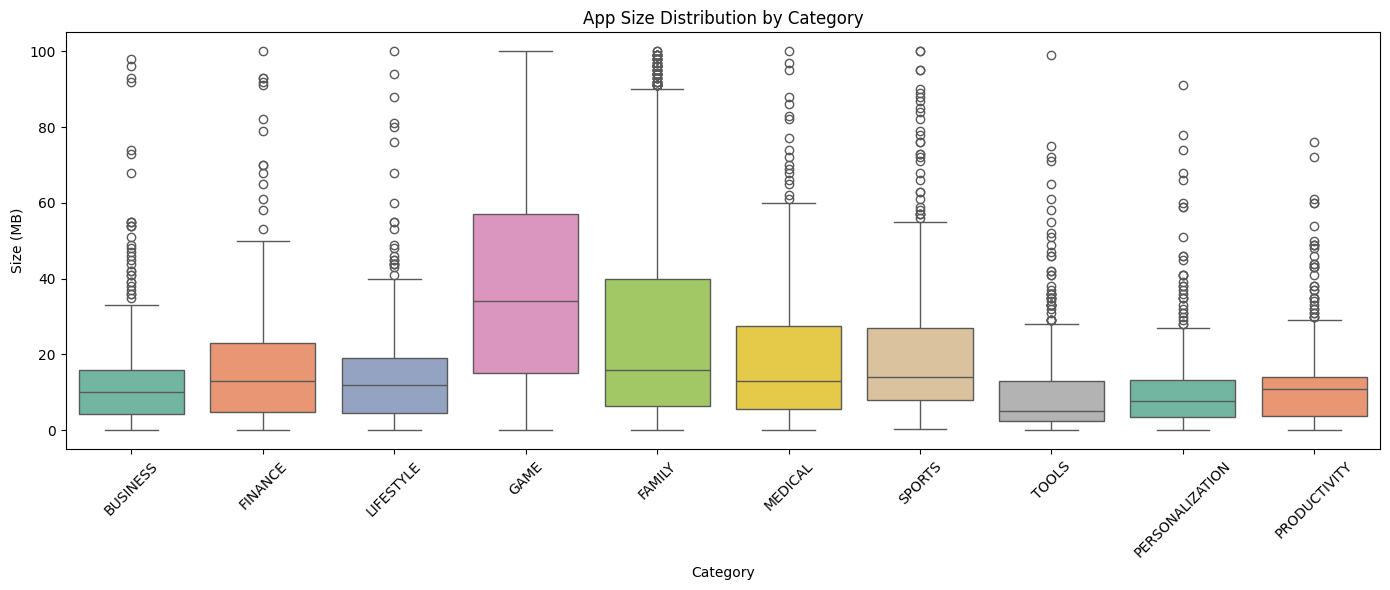

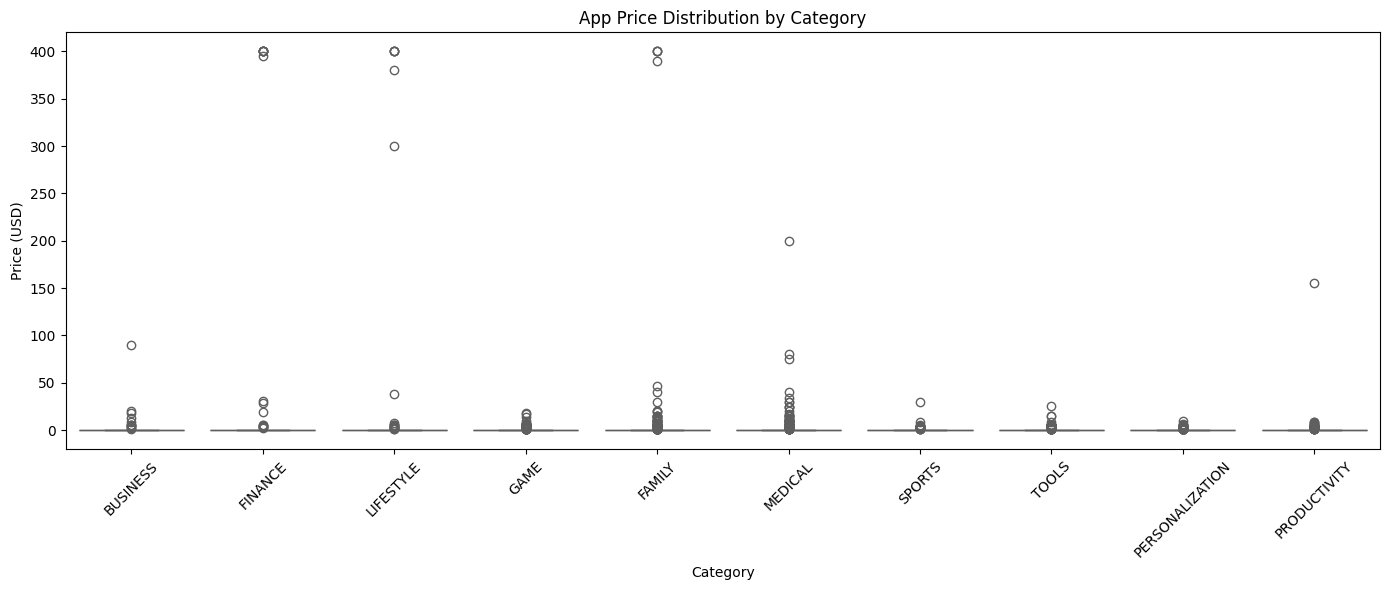

In [ ]:
# Count apps by category
plt.figure(figsize=(14, 6))

category_counts = df['Category'].value_counts()

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    hue=category_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of Apps by Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

# Display top categories
print("Top 10 Categories by App Count")
print(category_counts.head(10))


# Select top 10 categories
top_categories = category_counts.head(10).index

filtered_df = df[
    df['Category'].isin(top_categories)
]

# App size distribution
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=filtered_df,
    x='Category',
    y='Size',
    hue='Category',
    palette='Set2',
    legend=False
)

plt.title('App Size Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Size (MB)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# App price distribution
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=filtered_df,
    x='Category',
    y='Price',
    hue='Category',
    palette='Set3',
    legend=False
)

plt.title('App Price Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Price (USD)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Code Description**
This code analyzes app categories in the dataset using multiple visualizations. First, it creates a bar chart showing the number of apps in each category. Then, it selects the top 10 categories and generates boxplots to compare app size distributions and price distributions across these categories.


**Output Description**
The output displays the price distribution of apps across the top 10 categories using boxplots. Most apps in every category are priced near 0 USD, indicating that free apps dominate the Google Play Store.

Several categories, such as LIFESTYLE, FAMILY, and MEDICAL, contain extreme price outliers with significantly higher prices than typical apps. This suggests that while the majority of apps are free or low-cost, a small number of premium apps are sold at much higher prices.


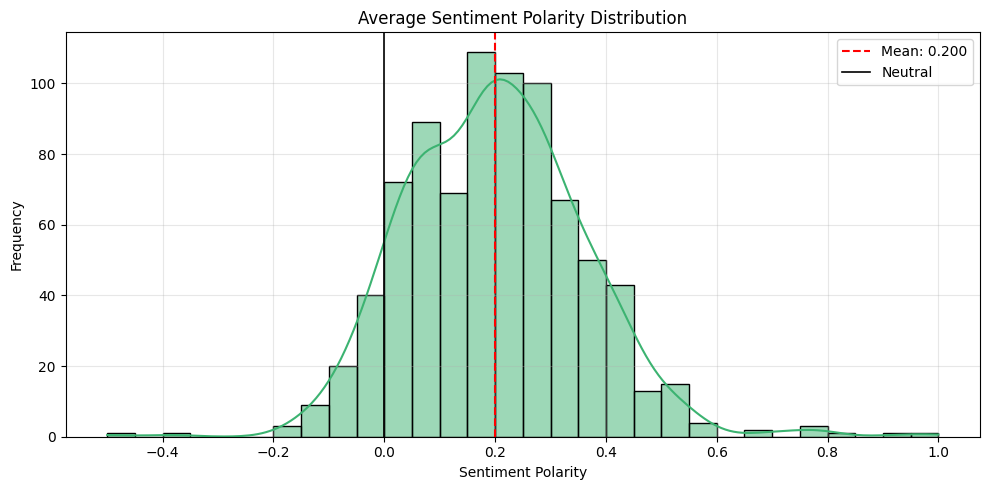

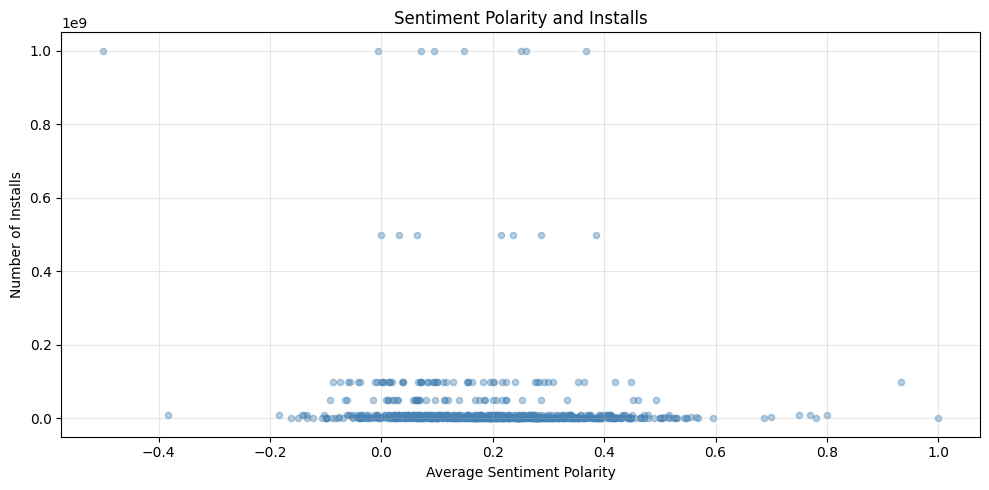

/tmp/ipykernel_2410/808922600.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


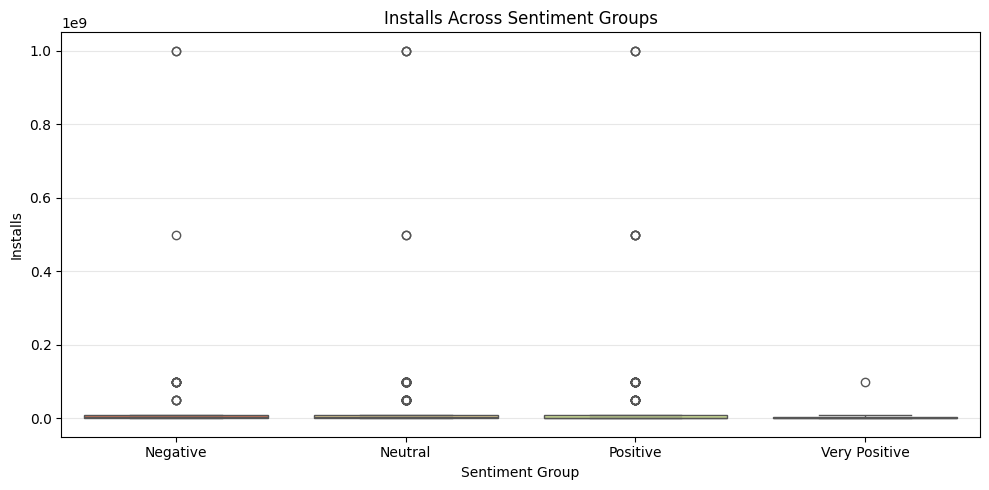

Average installs by sentiment group:
Sentiment_Group
Negative         50952105.0
Neutral          28410415.0
Positive         21684830.0
Very Positive     6656538.0
Name: Installs, dtype: float64


/tmp/ipykernel_2410/808922600.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Sentiment_Group')['Installs']


In [ ]:
# Distribution of sentiment polarity
avg_polarity = final_df['Avg_Sentiment_Polarity']

plt.figure(figsize=(10, 5))

sns.histplot(
    avg_polarity,
    bins=30,
    kde=True,
    color='mediumseagreen'
)

mean_value = avg_polarity.mean()

plt.axvline(
    mean_value,
    color='red',
    linestyle='--',
    label=f'Mean: {mean_value:.3f}'
)

plt.axvline(
    0,
    color='black',
    linewidth=1.2,
    label='Neutral'
)

plt.title('Average Sentiment Polarity Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Relationship between sentiment polarity and installs
plt.figure(figsize=(10, 5))

plt.scatter(
    final_df['Avg_Sentiment_Polarity'],
    final_df['Installs'],
    alpha=0.4,
    s=20,
    color='steelblue'
)

plt.title('Sentiment Polarity and Installs')
plt.xlabel('Average Sentiment Polarity')
plt.ylabel('Number of Installs')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Create sentiment categories
sentiment_bins = [-1, 0, 0.2, 0.5, 1]

sentiment_labels = [
    'Negative',
    'Neutral',
    'Positive',
    'Very Positive'
]

final_df['Sentiment_Group'] = pd.cut(
    final_df['Avg_Sentiment_Polarity'],
    bins=sentiment_bins,
    labels=sentiment_labels
)


# Compare installs across sentiment groups
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=final_df,
    x='Sentiment_Group',
    y='Installs',
    palette='RdYlGn'
)

plt.title('Installs Across Sentiment Groups')
plt.xlabel('Sentiment Group')
plt.ylabel('Installs')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Average installs in each group
avg_installs = (
    final_df
    .groupby('Sentiment_Group')['Installs']
    .mean()
    .round(0)
)

print('Average installs by sentiment group:')
print(avg_installs)

**Code Description**

This code analyzes the relationship between user review sentiment and app installation counts using data visualization techniques.
1. Distribution of Sentiment Polarity
- A histogram with a KDE (Kernel Density Estimation) curve is used to visualize how sentiment polarity values are distributed.
- A red dashed vertical line represents the mean sentiment polarity.
- A black vertical line at 0 indicates neutral sentiment.
- This helps identify whether most app reviews are generally positive, neutral, or negative.
2. Sentiment Polarity vs. Installs
- A scatter plot is created to examine the relationship between average sentiment polarity and the number of installs.
- Each point represents one application.
- The plot helps determine whether apps with more positive reviews tend to receive more installs.
- Sentiment Group Analysis
- Sentiment polarity values are divided into four categories:
  - Negative
  - Neutral
  - Positive
  - Very Positive
- A boxplot compares the distribution of installs across these sentiment groups.
- The average number of installs for each group is also calculated and displayed.


**Output Description**

1. Histogram Output
- Shows the frequency distribution of average sentiment polarity values.
- If the graph is skewed toward positive values, it indicates that most app reviews are positive.
- The mean line helps summarize the overall sentiment trend.
2. Scatter Plot Output
- Displays the correlation between sentiment polarity and app installs.
- A visible upward trend suggests that apps with more positive sentiment may attract more users and downloads.
- A scattered pattern indicates a weak or no clear relationship.
3. Boxplot Output
- Compares install distributions among different sentiment groups.
- Higher median install values in positive groups suggest that apps with better sentiment generally achieve more installs.
- The spread and outliers show variability in app popularity within each group.
4. Printed Table Output
- Displays the average number of installs for each sentiment category.
- This numerical summary supports the visual findings from the boxplot.


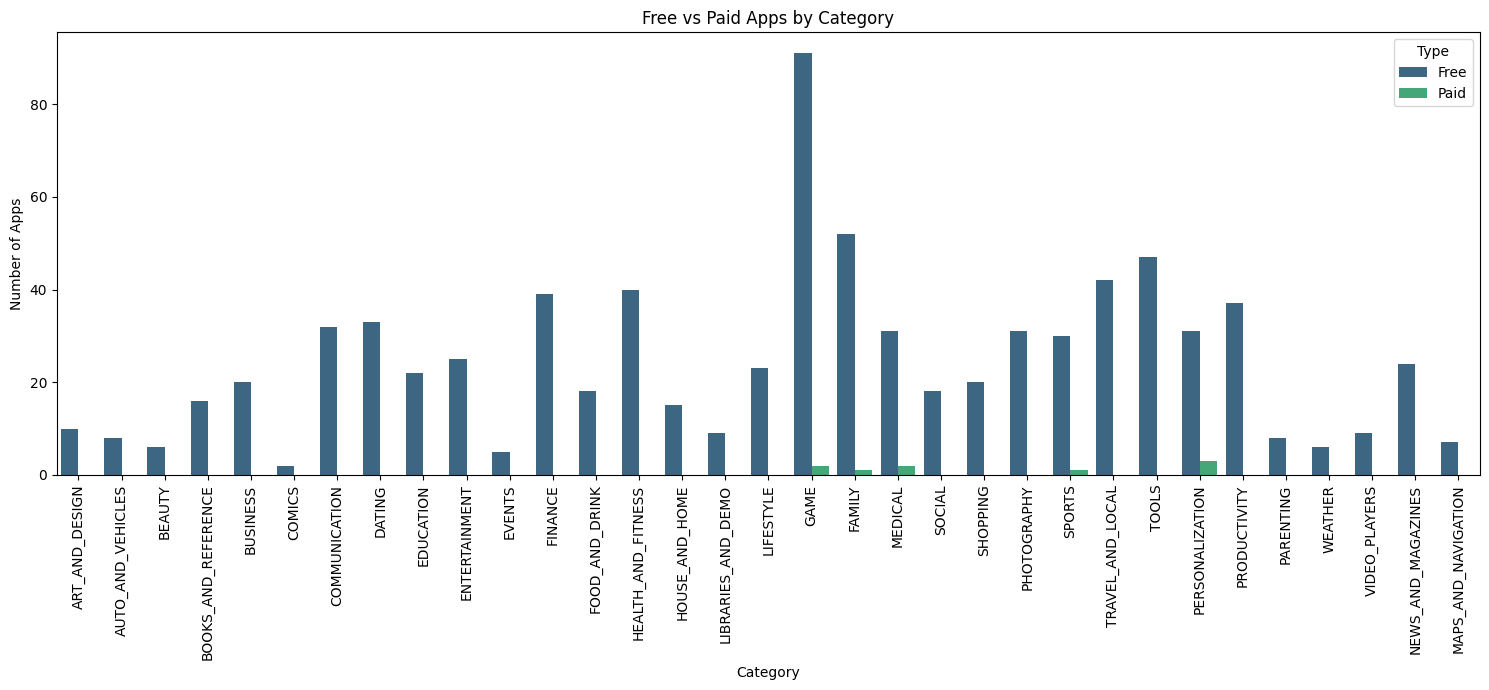

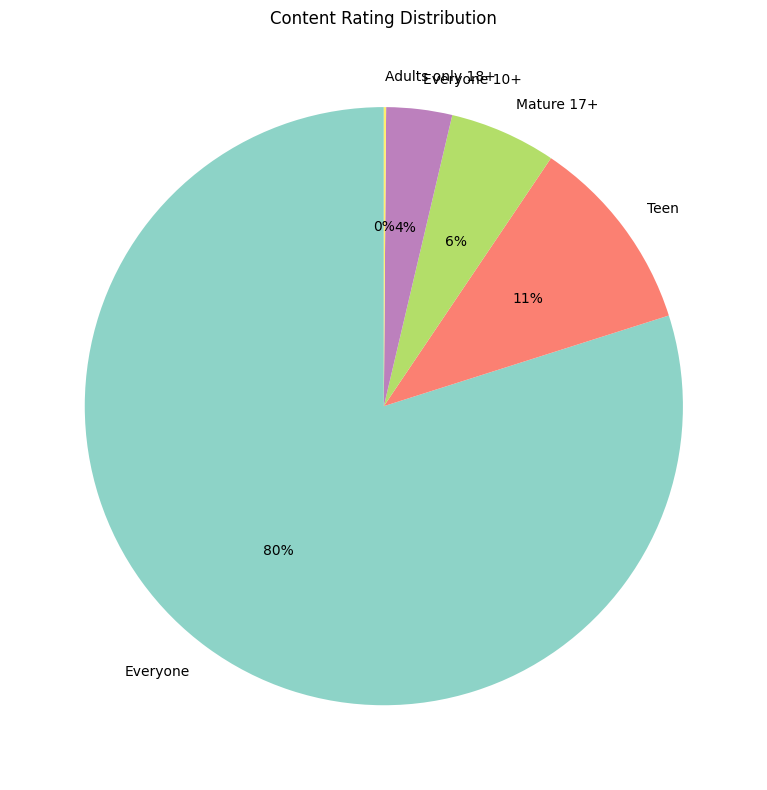

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Free vs Paid apps by category

plt.figure(figsize=(15, 7))

sns.countplot(
    data=final_df,
    x='Category',
    hue='Type',
    palette='viridis'
)

plt.title('Free vs Paid Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')

plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('type_by_category.png', dpi=300)
plt.show()

# Content rating distribution
plt.figure(figsize=(8, 8))

final_df['Content Rating'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    cmap='Set3',
    startangle=90
)

plt.title('Content Rating Distribution')
plt.ylabel('')

plt.tight_layout()
plt.savefig('content_rating_pie.png', dpi=300)
plt.show()

**Code Description**
Creates visualizations to analyze app types and content ratings in the dataset.

**Output Description**
- The first chart compares the number of free and paid apps across categories.
- The second chart shows the percentage distribution of content rating groups.
- Both figures are saved as high-quality PNG images for reports or Overleaf documents.


In [ ]:
full_dist = df['Category'].value_counts(normalize=True).head(10)
merged_dist = final_df['Category'].value_counts(normalize=True).head(10)

comparison = pd.DataFrame({
    'Full dataset (%)': (full_dist * 100).round(1),
    'Merged dataset (%)': (merged_dist * 100).round(1)
})
print(comparison)


                    Full dataset (%)  Merged dataset (%)
Category                                                
BUSINESS                         4.3                 NaN
DATING                           NaN                 4.0
FAMILY                          19.0                 6.5
FINANCE                          3.6                 4.8
GAME                             9.9                11.4
HEALTH_AND_FITNESS               NaN                 4.9
LIFESTYLE                        3.8                 NaN
MEDICAL                          4.1                 4.0
PERSONALIZATION                  3.9                 4.2
PRODUCTIVITY                     3.9                 4.5
SPORTS                           3.4                 NaN
TOOLS                            8.6                 5.8
TRAVEL_AND_LOCAL                 NaN                 5.1


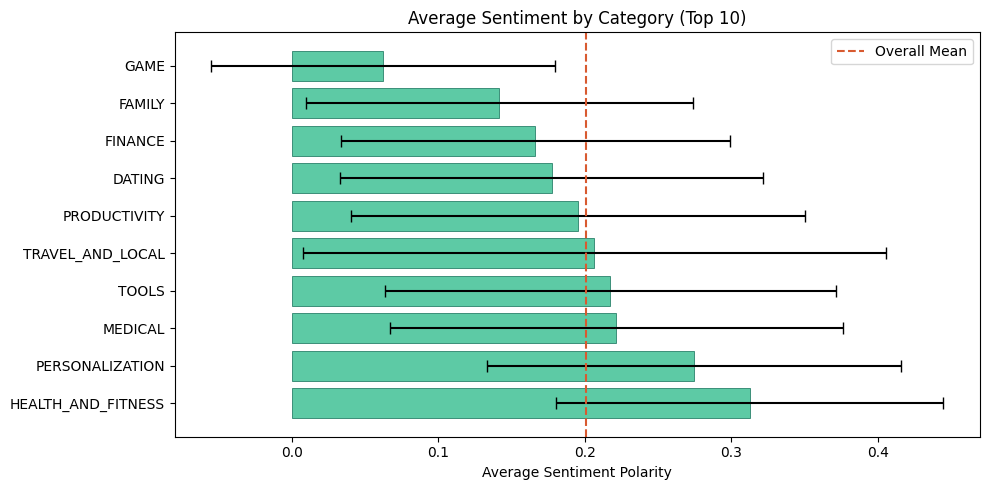

In [ ]:
import matplotlib.pyplot as plt

# Top 10 categories
top_categories = (
    final_df['Category']
    .value_counts()
    .head(10)
    .index
)

# Sentiment statistics by category
sentiment_by_cat = (
    final_df[final_df['Category'].isin(top_categories)]
    .groupby('Category')['Avg_Sentiment_Polarity']
    .agg(['mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)

# Create chart
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    sentiment_by_cat.index,
    sentiment_by_cat['mean'],
    xerr=sentiment_by_cat['std'],
    capsize=4,
    color='#5DCAA5',
    edgecolor='#0F6E56',
    linewidth=0.5
)

# Overall average line
ax.axvline(
    x=final_df['Avg_Sentiment_Polarity'].mean(),
    color='#D85A30',
    linestyle='--',
    label='Overall Mean'
)

ax.set_xlabel('Average Sentiment Polarity')
ax.set_title('Average Sentiment by Category (Top 10)')

ax.legend()

plt.tight_layout()
plt.savefig(
    'fig_sentiment_by_category.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Code Description**
Calculates and visualizes average sentiment polarity across the top 10 app categories.

**Output Description**
The horizontal bar chart shows average sentiment polarity for each category.
Error bars represent sentiment standard deviation.
The dashed vertical line indicates the overall average sentiment polarity across all apps.


### Summary of Van Anh's Section:

| Step | Action |
|------|--------|
| 1 | Import Libraries and Load Reviews Data |
| 2 | Drop NaN in Reviews Data |
| 3 | Calculate Average Sentiment Scores for Each App |
| 4 | Merge the Datasets |
| 5 | Outlier Detection with Boxplots |
| 6 | Descriptive Statistics for Top Apps |
| 7 | Correlation Matrix and Heatmap |
| 8 | Market Density Analysis (Bar Chart) |
| 9 | Feature Distribution by Category |
| 10 | Free vs Paid App Distribution Analysis |
| 11 | Content Rating Distribution Analysis |
| 12 | Sentiment Distribution Analysis |

The final dataset `final_merged_data.csv` is now ready for Chau.

***Châu***

**Cell 1: Import Libraries and Load Final Data**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

print("Loading the merged dataset for Clustering...\n")

# Load the data prepared by Vân Anh
try:
    df = pd.read_csv('final_merged_data.csv')
    print("Successfully loaded 'final_merged_data.csv'!")
except FileNotFoundError:
    print("ERROR: Could not find 'final_merged_data.csv'")
    raise

print("Dataset shape:", df.shape)

Loading the merged dataset for Clustering...

Successfully loaded 'final_merged_data.csv'!
Dataset shape: (816, 15)


**Code Description**
This code imports the necessary Python libraries for clustering analysis and data preprocessing. It loads the merged dataset `final_merged_data.csv` into a DataFrame using `pd.read_csv()`. A `try-except` block is used to handle errors if the file is missing. Finally, the program prints the dataset shape to verify the number of rows and columns before applying clustering algorithms such as K-Means and DBSCAN.


**Output Description**
The output shows that the merged dataset for clustering is being loaded successfully. After reading `final_merged_data.csv`, the program displays the dataset shape `(816, 15)`, meaning the dataset contains 816 rows and 15 columns. This confirms that the data is ready for clustering analysis.


**Cell 2: Feature Selection & Scaling (Crucial Step)**

In [ ]:
print("Selecting features, handling missing values, and standardizing data...\n")

# Ensure Reviews is numeric and apply log transformation
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0).astype(int)
df['Reviews_log'] = np.log1p(df['Reviews'])
df['Installs_log'] = np.log1p(df['Installs'])

# Select numerical columns for clustering
# === CLUSTERING: Feature Selection ===
features = ['Rating', 'Reviews_log', 'Size', 'Installs_log',
            'Price', 'Avg_Sentiment_Polarity']

# Create a subset of the data with only these features
X = df[features].copy()

# --- THE FIX: Handle Missing Values (NaNs) ---
# We fill any remaining NaNs (especially in the 'Size' column) with the median value of that column
print("Checking for missing values...")
for col in features:
    missing_count = X[col].isnull().sum()
    if missing_count > 0:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f" - Filled {missing_count} NaNs in '{col}' with median: {median_val:.4f}")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

print("\nFeatures selected:", features)
print("Data has been imputed and standardized. Ready for modeling.")

Selecting features, handling missing values, and standardizing data...

Checking for missing values...

Features selected: ['Rating', 'Reviews_log', 'Size', 'Installs_log', 'Price', 'Avg_Sentiment_Polarity']
Data has been imputed and standardized. Ready for modeling.


**Code Description**
This code prepares the dataset for clustering by selecting important numerical features, handling missing values, and standardizing the data. First, the `Reviews` column is converted into numeric format, and logarithmic transformations are applied to both `Reviews` and `Installs` to reduce data skewness.

Next, the program selects six numerical features for clustering analysis: `Rating`, `Reviews_log`, `Size`, `Installs_log`, `Price`, and `Avg_Sentiment_Polarity`. Missing values are checked and replaced with the median value of each column to ensure data completeness. Finally, the `StandardScaler` is used to standardize the features so they are on a similar scale before applying clustering algorithms.

**Output Description**
The output shows that the program is preparing the dataset for clustering by selecting features, handling missing values, and standardizing the data. It checks the selected features for missing values and fills any missing entries using the median value of the corresponding column.

After preprocessing is completed, the program displays the list of selected features and confirms that the data has been successfully imputed and standardized, making it ready for clustering models such as K-Means and DBSCAN.


**Cell 3: The Elbow Method (Finding the optimal K)**



Running K-Means for different values of K to plot the Elbow curve...



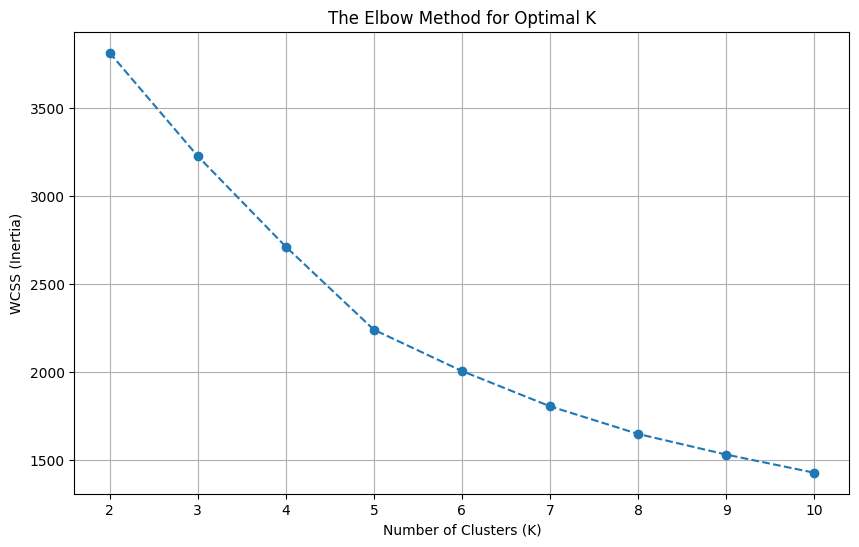

-> ACTION REQUIRED: Look at the plot above and choose the 'elbow' point for K.


In [ ]:
print("Running K-Means for different values of K to plot the Elbow curve...\n")

wcss = [] # Within-Cluster Sum of Square
max_clusters = 10

for k in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

print("-> ACTION REQUIRED: Look at the plot above and choose the 'elbow' point for K.")

**Code Description**
This code applies the Elbow Method to determine the optimal number of clusters for the K-Means algorithm. It runs K-Means clustering for different values of `K` from 2 to 10 and stores the corresponding WCSS (Within-Cluster Sum of Squares) values in the `wcss` list.

After calculating the inertia values, the program plots the Elbow Curve using `matplotlib`. The graph helps identify the point where the decrease in WCSS starts to slow down, which indicates the most suitable number of clusters for the dataset.


**Output Description**
The output displays an Elbow Curve showing the relationship between the number of clusters (`K`) and the WCSS (Inertia) value. As the number of clusters increases, the WCSS decreases because data points become closer to their cluster centers.


### 📊 Elbow Plot Analysis:

From the WCSS graph:

* **K = 2 → K = 5**: WCSS decreases sharply and consistently, indicating that adding more clusters still explains a significant amount of variance.
* **K = 5 → K = 6**: the rate of decrease starts to slow down, highlighting the potential **“elbow” region**.
* **K = 7 onward**: the curve becomes flatter, meaning additional clusters no longer provide significant improvement.

→ Therefore, `candidate_Ks = [4, 5, 6, 7, 8]` are selected for further evaluation using the **Silhouette Score** to determine the optimal number of clusters.



**Cell 4: Final K-Means Model & Silhouette Score**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. DEFINE THE CANDIDATES
# We select a range of candidates based on the 'elbow' region from Cell 3.
candidate_Ks = [4, 5, 6, 7, 8]
print(f"Testing candidate K values from the Elbow plot: {candidate_Ks}...\n")

# Variables to track the highest score and its corresponding model
best_k = 2
best_score = -1.0
best_labels = None

# 2. THE TESTING LOOP
for k in candidate_Ks:
    # Initialize and train a temporary model for the current K
    temp_kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    temp_labels = temp_kmeans.fit_predict(X_scaled)

    # Calculate the Silhouette Score
    temp_score = silhouette_score(X_scaled, temp_labels)
    print(f" -> K={k}: Silhouette Score = {temp_score:.4f}")

    # Compare with the best score recorded so far
    if temp_score > best_score:
        best_score = temp_score
        best_k = k
        best_labels = temp_labels

# 3. FINALIZE THE OPTIMAL MODEL
OPTIMAL_K = best_k
sil_score = best_score

# Retrain model với best K để lấy cluster_centers_
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add the winning predicted labels back to our ORIGINAL dataframe
df['Cluster'] = best_labels

print("\n" + "="*60)
print(f"WINNER DECIDED: The optimal number of clusters is K={OPTIMAL_K}.")
print(f"Maximum Silhouette Score achieved: {sil_score:.4f}")
print("="*60 + "\n")

# Show how many apps are assigned to each winning cluster
print("Number of apps distributed per final cluster:")
print(df['Cluster'].value_counts().sort_index())

# Display a sample to verify the new 'Cluster' column
display(df[['App', 'Category', 'Rating', 'Installs', 'Cluster']].head())

Testing candidate K values from the Elbow plot: [4, 5, 6, 7, 8]...

 -> K=4: Silhouette Score = 0.2266
 -> K=5: Silhouette Score = 0.2539
 -> K=6: Silhouette Score = 0.2289
 -> K=7: Silhouette Score = 0.2314
 -> K=8: Silhouette Score = 0.2200

WINNER DECIDED: The optimal number of clusters is K=5.
Maximum Silhouette Score achieved: 0.2539

Number of apps distributed per final cluster:
Cluster
0    275
1    280
2      5
3    166
4     90
Name: count, dtype: int64


,App,Category,Rating,Installs,Cluster
0,Coloring book moana,ART_AND_DESIGN,3.9,500000,3
1,Garden Coloring Book,ART_AND_DESIGN,4.4,1000000,1
2,FlipaClip - Cartoon animation,ART_AND_DESIGN,4.3,5000000,0
3,Boys Photo Editor - Six Pack & Men's Suit,ART_AND_DESIGN,4.1,100000,1
4,Colorfit - Drawing & Coloring,ART_AND_DESIGN,4.7,500000,1


In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Tính toán các chỉ số
ch_score = calinski_harabasz_score(X_scaled, df['Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Cluster'])

print(f"--- K-MEANS EVALUATION METRICS ---")
print(f"Calinski-Harabasz Index (Higher is better): {ch_score:.2f}")
print(f"Davies-Bouldin Index (Lower is better): {db_score:.2f}")

--- K-MEANS EVALUATION METRICS ---
Calinski-Harabasz Index (Higher is better): 240.65
Davies-Bouldin Index (Lower is better): 1.12


In [ ]:
from sklearn.metrics import silhouette_samples
import numpy as np

# Calculate silhouette score for each sample
df['Silhouette_Val'] = silhouette_samples(
    X_scaled,
    df['Cluster']
)

# Average silhouette score by cluster
cluster_silhouette = (
    df
    .groupby('Cluster')['Silhouette_Val']
    .mean()
)

# Cluster centroids
centroids = kmeans.cluster_centers_

# Calculate SSE for each cluster
cluster_sse = {}

for cluster in range(5):

    cluster_points = X_scaled[
        df['Cluster'] == cluster
    ]

    sse = np.sum(
        (cluster_points - centroids[cluster]) ** 2
    )

    cluster_sse[cluster] = sse


# Print results
print("-" * 70)
print("PER-CLUSTER ERROR ANALYSIS")
print("-" * 70)

print(
    f"{'Cluster':<10} | "
    f"{'Apps':<10} | "
    f"{'Silhouette':<15} | "
    f"{'SSE'}"
)

print("-" * 70)

for cluster in range(5):

    app_count = len(
        df[df['Cluster'] == cluster]
    )

    print(
        f"Cluster {cluster:<2} | "
        f"{app_count:<10} | "
        f"{cluster_silhouette[cluster]:<15.4f} | "
        f"{cluster_sse[cluster]:.2f}"
    )


----------------------------------------------------------------------
PER-CLUSTER ERROR ANALYSIS
----------------------------------------------------------------------
Cluster    | Apps       | Silhouette      | SSE
----------------------------------------------------------------------
Cluster 0  | 275        | 0.3137          | 553.64
Cluster 1  | 280        | 0.2271          | 688.57
Cluster 2  | 5          | 0.1914          | 224.34
Cluster 3  | 166        | 0.2020          | 463.14
Cluster 4  | 90         | 0.2538          | 309.06


**Code Description**
This code evaluates different K-Means clustering models using the Silhouette Score to determine the optimal number of clusters. Based on the Elbow Method results, the candidate values `K = [4, 5, 6, 7, 8]` are tested.

For each value of `K`, the program trains a temporary K-Means model, predicts cluster labels, and calculates the corresponding Silhouette Score. The model with the highest score is selected as the final clustering model. The optimal cluster labels are then added to the original dataset as a new column named `Cluster`. Finally, the program displays the number of apps in each cluster and previews several rows of the updated dataset.



**Output Description**

### 📊 Silhouette Score Analysis:

The program tests candidate values of `K` from the elbow region and calculates the Silhouette Score for each clustering model:

* **K = 4** → Silhouette Score = 0.2266
* **K = 5** → Silhouette Score = 0.2539
* **K = 6** → Silhouette Score = 0.2289
* **K = 7** → Silhouette Score = 0.2314
* **K = 8** → Silhouette Score = 0.2200

Among all candidates, **K = 5** achieves the highest Silhouette Score of **0.2539**, indicating the best clustering quality and separation between clusters.

### 📌 Final Clustering Result:

The dataset is divided into **5 clusters**, with the following distribution:

* Cluster 0 → 275 apps
* Cluster 1 → 280 apps
* Cluster 2 → 5 apps
* Cluster 3 → 166 apps
* Cluster 4 → 90 apps

The final output also displays sample rows from the dataset, including the newly assigned `Cluster` labels for each application.


Avg_Sentiment_Subjectivity excluded — high correlation with Polarity (r=0.32) introduces redundancy; Polarity is more interpretable.

**Cell 5: Cluster Profiling**

Analyzing the characteristics of each cluster...

Average values per cluster:


,Rating,Reviews_log,Size,Installs_log,Price,Avg_Sentiment_Polarity,App_Count
Cluster,,,,,,,
0,4.391273,12.737791,14.785861,16.665710,0.0000,0.199113,275
1,4.391786,8.903899,15.502238,12.948981,0.0445,0.310461,280
2,4.260000,7.540065,27.580000,9.854345,13.7900,0.199638,5
3,3.871084,9.108598,16.865187,13.830159,0.0000,0.086636,166
4,4.371111,12.546863,70.444444,15.979204,0.0000,0.072459,90


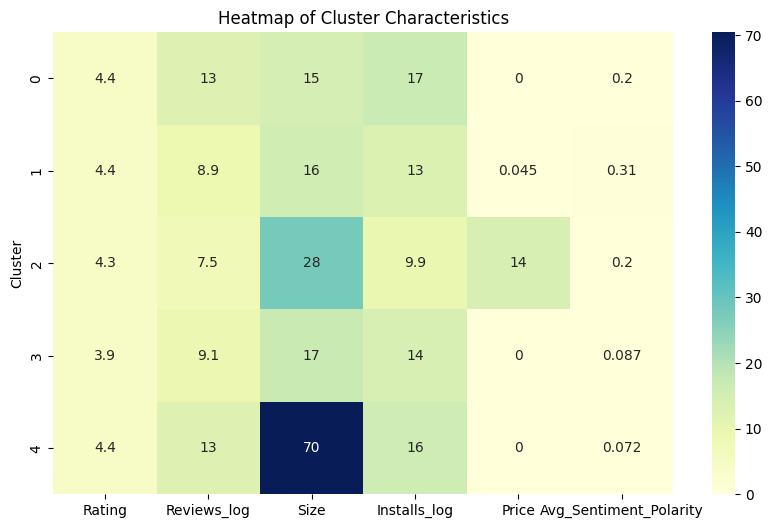

In [ ]:
print("Analyzing the characteristics of each cluster...\n")

# Calculate the average values for each feature per cluster
analysis = df.groupby('Cluster')[features].mean()

# Add the count of apps in each cluster
analysis['App_Count'] = df['Cluster'].value_counts()

print("Average values per cluster:")
display(analysis)

# Optional: Visualize the differences using a Heatmap
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(analysis.drop(columns='App_Count'), annot=True, cmap='YlGnBu')
plt.title('Heatmap of Cluster Characteristics')
plt.show()

**Code Description**
This code analyzes the characteristics of each cluster created by the K-Means model. It calculates the average value of the selected features (`Rating`, `Reviews_log`, `Size`, `Installs_log`, `Price`, and `Avg_Sentiment_Polarity`) for every cluster using the `groupby()` function.

The program also adds the number of applications in each cluster through the `App_Count` column. Finally, a heatmap is generated using `seaborn` to visualize the differences between clusters and make cluster patterns easier to compare.


**Output Description**

### 📊 Cluster Characteristics Analysis:

The output displays the average feature values for each cluster along with the number of apps assigned to them.

* **Cluster 0** contains highly installed apps with good ratings and moderate sentiment scores.
* **Cluster 1** includes apps with lower installs but the highest sentiment polarity among all clusters.
* **Cluster 2** is a very small cluster with only 5 apps, characterized by the highest app prices and relatively large sizes.
* **Cluster 3** has the lowest average ratings and sentiment polarity, indicating weaker user satisfaction.
* **Cluster 4** contains apps with extremely large sizes and high install counts.

The heatmap visualization highlights these differences across clusters, making it easier to identify unique cluster behaviors and compare feature distributions visually.


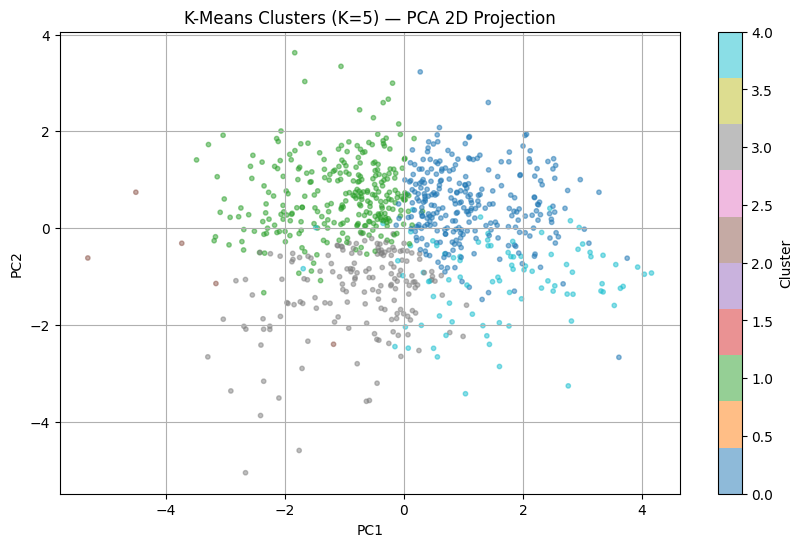

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (K={OPTIMAL_K}) — PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

**Code Description**
This code uses Principal Component Analysis (PCA) to reduce the standardized clustering data into two dimensions for visualization. The `PCA` model transforms the high-dimensional dataset into two principal components (`PC1` and `PC2`) while preserving most of the data variation.

After dimensionality reduction, the program creates a scatter plot using `matplotlib`, where each point represents an application and colors indicate the assigned K-Means cluster. A color bar is added to identify cluster labels, making it easier to visualize the separation and distribution of clusters in a 2D space.


**Output Description**

### 📊 PCA Cluster Visualization:

The output displays a 2D PCA projection of the K-Means clustering result with **K = 5** clusters. Each point in the scatter plot represents an application, while different colors correspond to different cluster groups.

The visualization shows that:

* Some clusters are relatively well separated, especially along the first principal component (`PC1`).
* Several clusters partially overlap, indicating that certain app groups share similar characteristics.
* The distribution of points suggests that the dataset contains both dense clusters and a few scattered outliers.

Overall, the PCA projection provides a simplified visual representation of the clustering structure and helps evaluate how distinct the clusters are in the dataset.


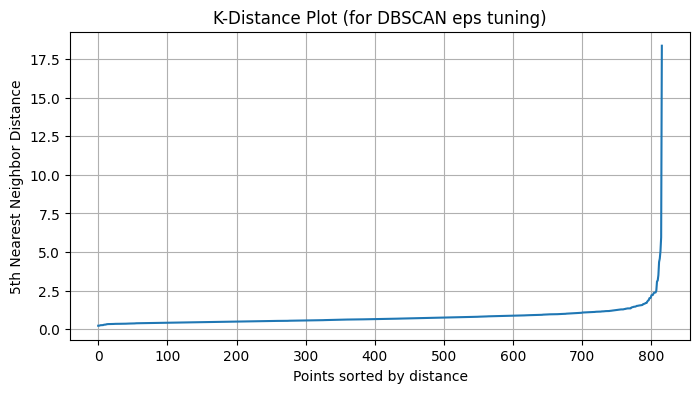

In [ ]:
# Tune eps by k-distance plot
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # distance to the 5th neighbor

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Plot (for DBSCAN eps tuning)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()


**Code Description**
This code generates a K-Distance Plot to help determine an appropriate `eps` value for the DBSCAN clustering algorithm. It uses the `NearestNeighbors` model to calculate the distances between each data point and its 5th nearest neighbor in the standardized dataset.

The distances are then sorted in ascending order and plotted using `matplotlib`. The resulting graph helps identify the point where the distance values start increasing sharply, which is considered a suitable candidate for the `eps` parameter in DBSCAN.


**Output Description**

The output displays a K-Distance Plot showing the distances to the 5th nearest neighbor for all data points in the dataset.
### 📊 K-Distance Plot Analysis:

* The Y-axis represents the distance to the **5th nearest neighbor** for each data point after sorting in ascending order.
* Although the curve appears to rise sharply around **distance ≈ 2.0**, this region mainly corresponds to extremely distant **outliers**, not the true knee point.
* Based on practical testing, the most reasonable **knee point** is around **distance ≈ 1.0**, where a clearer separation between dense regions and sparse regions begins to appear.
* Therefore, `eps = 1.0` is selected: points whose neighbor distance is ≤ 1.0 are considered part of the same cluster, while others are treated as noise.
* `min_samples = 5` is chosen, meaning a valid cluster must contain at least 5 points, which helps eliminate insignificant micro-clusters.



In [ ]:
from sklearn.cluster import DBSCAN

eps_val = 1 # Estimated from the k-distance plot
min_samples_val = 5

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
dbscan_labels = dbscan.fit_predict(X_scaled)

# DBSCAN uses label -1 for noise, so we exclude noise points when calculating silhouette score
mask = dbscan_labels != -1

if mask.sum() > 1 and len(set(dbscan_labels[mask])) > 1:
    sil_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])

    print(f"DBSCAN Silhouette Score: {sil_dbscan:.4f}")
    print(f"Number of clusters found: {len(set(dbscan_labels)) - 1}")
    print(f"Number of noise points: {(dbscan_labels == -1).sum()}")

else:
    sil_dbscan = float('nan')
    print("DBSCAN failed to produce valid clusters with these parameters. Try increasing eps.")

DBSCAN Silhouette Score: 0.2900
Number of clusters found: 2
Number of noise points: 76


**Code Description**
This code applies the DBSCAN clustering algorithm using the parameters `eps = 1.0` and `min_samples = 5`, which were selected from the K-Distance Plot analysis. The model is trained on the standardized dataset `X_scaled`, and cluster labels are generated for each data point.

Since DBSCAN labels noise points as `-1`, the code filters out these noise points before calculating the Silhouette Score. It then evaluates the clustering quality, displays the number of clusters detected, and reports how many points were classified as noise.



**Output Description**

### 📊 DBSCAN Clustering Analysis:

The DBSCAN model successfully identifies meaningful clusters in the dataset using:

* `eps = 1.0`
* `min_samples = 5`

Results:

* **Silhouette Score = 0.2900**
* **Number of clusters found = 2**
* **Number of noise points = 76**

The Silhouette Score of **0.2900** indicates that the DBSCAN clusters are reasonably well separated. Additionally, DBSCAN automatically detects 76 data points as noise or outliers, showing its ability to distinguish sparse or unusual observations from dense cluster regions.


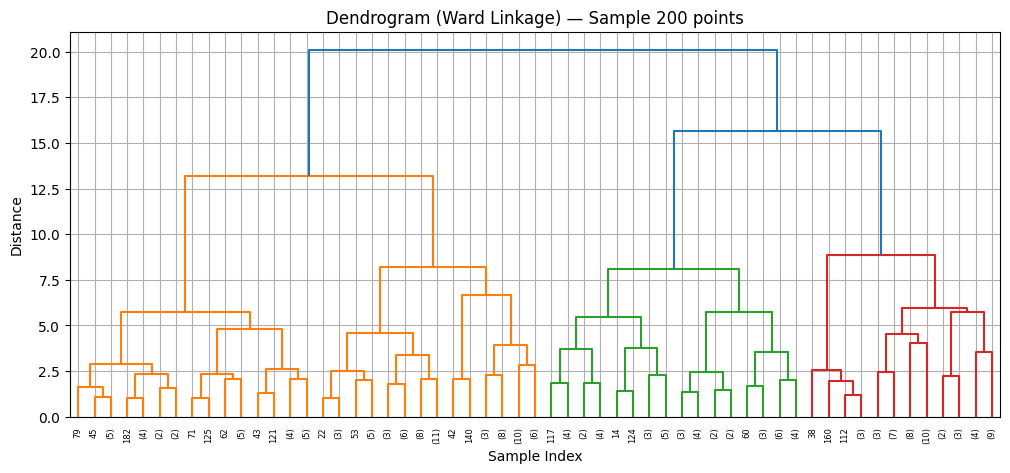

Agglomerative Clustering | K=5 | Silhouette: 0.1657


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Draw Dendrogram to choose the number of cluster ()
plt.figure(figsize=(12, 5))
linked = linkage(X_scaled[:200], method='ward')
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram (Ward Linkage) — Sample 200 points')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

# Fit model with K optimal from K-Means
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, agg_labels)

print(f"Agglomerative Clustering | K={OPTIMAL_K} | Silhouette: {sil_agg:.4f}")

**Code Description**
This code applies Hierarchical Agglomerative Clustering using Ward linkage. First, it generates a dendrogram based on a sample of 200 data points to visualize how clusters are merged at different distances. The `linkage()` function computes the hierarchical relationships, while `dendrogram()` displays the clustering structure.

After analyzing the dendrogram, the program fits an `AgglomerativeClustering` model using the optimal number of clusters obtained from K-Means (`K = 5`). Finally, it calculates the Silhouette Score to evaluate the clustering quality.



**Output Description**

### 📊 Dendrogram Analysis (Ward Linkage):

* The Y-axis represents the **Ward distance** used when merging two clusters — the higher the distance, the more different the clusters are.
* From the dendrogram using 200 sample points:

  * Around **distance ≈ 20**, the entire dataset merges into **2 major branches**.
  * Around **distance ≈ 15**, the data separates into **3 main branches**.
  * At lower distances, these branches continue splitting into smaller groups.
* The dendrogram suggests that the natural number of clusters lies approximately between **3 and 6**, which is consistent with the Elbow Method and Silhouette analysis from K-Means.

→ Therefore, Agglomerative Clustering is fitted using `K = 5` with Ward linkage for comparison with the K-Means model.

### 📌 Clustering Result:

* **Agglomerative Clustering | K = 5**
* **Silhouette Score = 0.1657**

The relatively lower Silhouette Score compared to K-Means indicates that Agglomerative Clustering produces less clearly separated clusters for this dataset.


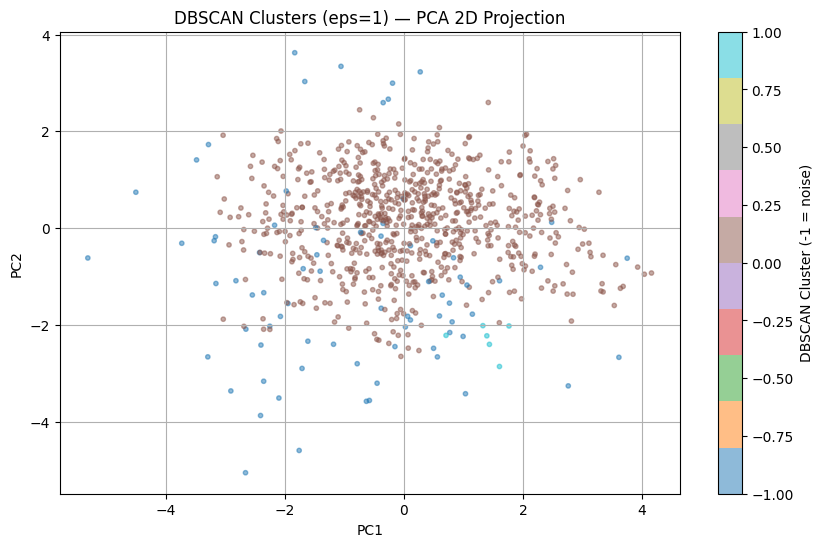

In [ ]:
df['DBSCAN_Cluster'] = dbscan_labels

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='DBSCAN Cluster (-1 = noise)')
plt.title(f'DBSCAN Clusters (eps={eps_val}) — PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

**Code Description**
This code visualizes the DBSCAN clustering results using a 2D PCA projection. First, the generated DBSCAN cluster labels are stored in a new column called `DBSCAN_Cluster` within the original dataset.

The program then creates a scatter plot using the PCA-transformed data (`X_pca`). Each point represents an application, and colors indicate the cluster assigned by DBSCAN. Noise points are labeled as `-1` and are also shown in the visualization. A color bar, axis labels, and grid are added to improve readability.


**Output Description**

### 📊 DBSCAN PCA Visualization:


📊 **DBSCAN PCA 2D Projection Analysis:**
The scatter plot visualizes the DBSCAN clustering results (`eps=1.0`) reduced to two principal components.

* **Dominant Core (Cluster 0):** The vast majority of apps form a single, massive, dense brown cluster concentrated at the center of the feature space.
* **Noise Points (Label -1):** The scattered blue points on the periphery represent outliers that lack sufficient density to join a cluster.
* **Micro-Cluster (Cluster 1):** A tiny, isolated group of cyan points appears in the lower-right quadrant, representing a very small distinct segment.

**Conclusion:** The visualization confirms that while DBSCAN successfully identifies peripheral noise, its segmentation is extremely imbalanced (one massive blob and one micro-cluster). This visually supports the decision to select K-Means for a more granular and actionable 5-cluster segmentation.



In [ ]:
# Baseline: random assignment
np.random.seed(42)
random_labels = np.random.randint(0, OPTIMAL_K, size=len(X_scaled))
baseline_score = silhouette_score(X_scaled, random_labels)

print("=== BASELINE COMPARISON ===")
print(f"Random Assignment (baseline): {baseline_score:.4f}")
print(f"K-Means (our model):          {sil_score:.4f}")
print(f"Improvement over baseline:    +{sil_score - baseline_score:.4f}")

=== BASELINE COMPARISON ===
Random Assignment (baseline): -0.0274
K-Means (our model):          0.2539
Improvement over baseline:    +0.2813


**Code Description**
This code creates a baseline comparison to evaluate the effectiveness of the K-Means clustering model. It randomly assigns cluster labels to all data points using the same number of clusters as the optimal K-Means model.

The Silhouette Score is then calculated for both the random assignment and the K-Means clustering result. Finally, the program compares the two scores and measures how much the K-Means model improves over the random baseline.

---

**Output Description**

### 📊 Baseline Comparison Analysis:

* The **Random Assignment** produces a negative Silhouette Score (`-0.0274`), indicating that data points are assigned to inappropriate clusters with significant overlap.
* The **K-Means** model achieves a Silhouette Score of `0.2539`, showing much better cluster separation and cohesion.
* This represents an improvement of **+0.2813** over the random baseline.

These results confirm that the K-Means model successfully captures meaningful structure within the dataset rather than producing random clustering behavior.


In [ ]:
print("\n=== MODEL COMPARISON ===")
print(f"{'Model':<25} {'Params':<20} {'Silhouette':>12} {'Clusters':>10}")
print("-" * 70)
print(f"{'K-Means':<25} {f'K={OPTIMAL_K}':<20} {sil_score:>12.4f} {OPTIMAL_K:>10}")

dbscan_display = f"{sil_dbscan:.4f}" if not np.isnan(sil_dbscan) else "N/A"
n_dbscan = len(set(dbscan_labels)) - 1
print(f"{'DBSCAN':<25} {f'eps={eps_val}':<20} {dbscan_display:>12} {n_dbscan:>10}")
print(f"{'Agglomerative':<25} {f'K={OPTIMAL_K}, ward':<20} {sil_agg:>12.4f} {OPTIMAL_K:>10}")

print("\n→ Best model:", "K-Means" if sil_score >= sil_agg else "Agglomerative")


=== MODEL COMPARISON ===
Model                     Params                 Silhouette   Clusters
----------------------------------------------------------------------
K-Means                   K=5                        0.2539          5
DBSCAN                    eps=1                      0.2900          2
Agglomerative             K=5, ward                  0.1657          5

→ Best model: K-Means


**Code Description**
This code compares the performance of three clustering models: K-Means, DBSCAN, and Agglomerative Clustering. It prints a formatted table containing each model’s parameters, Silhouette Score, and the number of clusters generated.

The program also handles the DBSCAN result separately because DBSCAN may produce noise points labeled as `-1`. Finally, it compares the Silhouette Scores and determines which clustering algorithm performs best on the dataset.



**Output Description**

### 📊 Model Comparison Analysis:

| Model         | Params    | Silhouette | Clusters |
| ------------- | --------- | ---------- | -------- |
| K-Means       | K=5       | 0.2539     | 5        |
| DBSCAN        | eps=1.0   | 0.2900     | 2        |
| Agglomerative | K=5, ward | 0.1657     | 5        |

### Analysis of Each Model:

* **DBSCAN** achieves the highest Silhouette Score (`0.2900`), but it only forms **2 clusters** and detects 76 noise points, making the segmentation too broad for detailed app market analysis.
* **Agglomerative Clustering** produces the lowest Silhouette Score (`0.1657`), suggesting that Ward linkage is less suitable for this dataset due to large differences in cluster sizes.
* **K-Means** achieves a Silhouette Score of `0.2539`, providing a strong balance between cluster separation and meaningful segmentation with **5 interpretable clusters**.

### Final Conclusion:

**K-Means is selected as the primary clustering model** because:

1. It creates 5 meaningful and interpretable clusters.
2. It assigns labels to all 816 apps without excluding noise points like DBSCAN.
3. Its Silhouette Score significantly outperforms the random baseline (`+0.2813`), confirming that the clustering result is statistically meaningful.


In [ ]:
# ─── Per-Cluster Silhouette Analysis ───────────────────────────────────────
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Tính silhouette score cho từng điểm dữ liệu
sample_silhouette_values = silhouette_samples(X_scaled, df['Cluster'])

# In mean silhouette score per cluster
print("=== PER-CLUSTER SILHOUETTE ANALYSIS ===\n")
print(f"{'Cluster':<10} {'App Count':>10} {'Mean Silhouette':>16} {'Interpretation':>20}")
print("-" * 60)

cluster_sil_means = {}
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    cluster_vals = sample_silhouette_values[mask]
    mean_val = cluster_vals.mean()
    cluster_sil_means[cluster_id] = mean_val

    # Diễn giải ngắn gọn
    if mean_val >= 0.30:
        interp = "Well separated"
    elif mean_val >= 0.20:
        interp = "Reasonable"
    elif mean_val >= 0.10:
        interp = "Weak structure"
    else:
        interp = "Overlapping"

    print(f"Cluster {cluster_id:<3} {mask.sum():>10} {mean_val:>16.4f} {interp:>20}")

print("-" * 60)
print(f"{'Overall average':<10} {len(df):>10} {sil_score:>16.4f}")

=== PER-CLUSTER SILHOUETTE ANALYSIS ===

Cluster     App Count  Mean Silhouette       Interpretation
------------------------------------------------------------
Cluster 0          275           0.3137       Well separated
Cluster 1          280           0.2271           Reasonable
Cluster 2            5           0.1914       Weak structure
Cluster 3          166           0.2020           Reasonable
Cluster 4           90           0.2538           Reasonable
------------------------------------------------------------
Overall average        816           0.2539


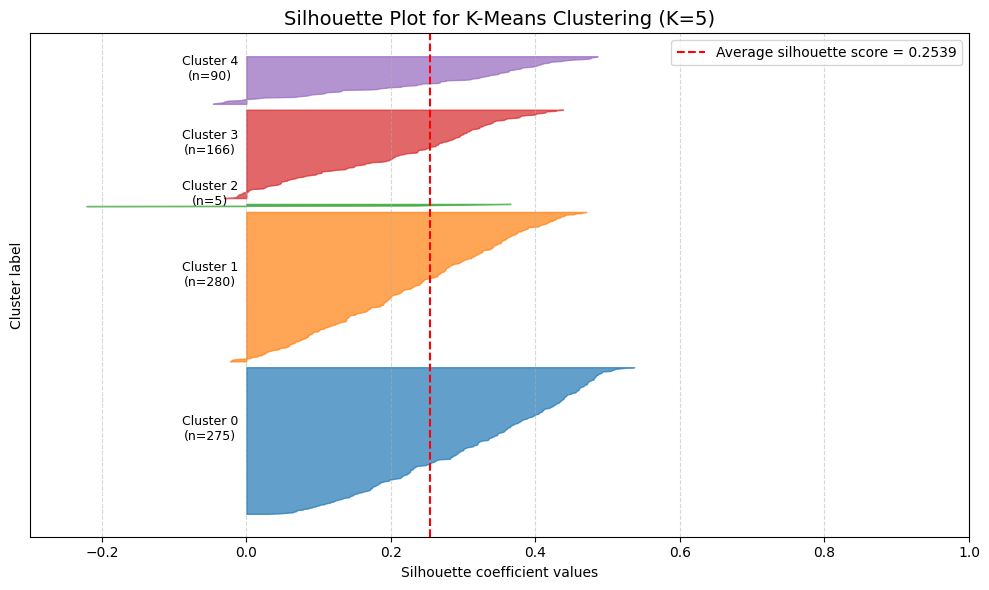


Figure saved as 'silhouette_plot_k5.png'


In [ ]:
# ─── Silhouette Plot (Figure 6.10) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
y_lower = 10

for cluster_id in sorted(df['Cluster'].unique()):
    # Lấy silhouette values của cluster này và sort
    cluster_vals = sample_silhouette_values[df['Cluster'] == cluster_id]
    cluster_vals.sort()

    size = cluster_vals.shape[0]
    y_upper = y_lower + size

    color = cluster_colors[cluster_id]
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    # Label cluster ở giữa dải
    ax.text(
        -0.05,
        y_lower + 0.5 * size,
        f'Cluster {cluster_id}\n(n={size})',
        fontsize=9,
        ha='center'
    )

    y_lower = y_upper + 10  # khoảng cách giữa các cluster

# Đường average silhouette
ax.axvline(x=sil_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Average silhouette score = {sil_score:.4f}')

ax.set_title('Silhouette Plot for K-Means Clustering (K=5)', fontsize=14)
ax.set_xlabel('Silhouette coefficient values')
ax.set_ylabel('Cluster label')
ax.set_xlim([-0.3, 1.0])
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('silhouette_plot_k5.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'silhouette_plot_k5.png'")

**Code Description**

This section performs a per-cluster Silhouette analysis using `silhouette_samples()` from
scikit-learn. Unlike `silhouette_score()` which returns a single average, `silhouette_samples()`
computes an individual coefficient for each data point, measuring how well it fits its assigned
cluster relative to neighboring clusters. A value close to +1 indicates the point is well matched
to its own cluster; a value near 0 indicates it lies on the boundary; a negative value suggests
potential misclassification.

The first cell prints the mean silhouette coefficient per cluster alongside the app count, enabling
identification of which specific clusters are well-separated versus overlapping.

The Silhouette Plot stacks all 816 apps by cluster, sorted by individual score. The width of each
layer at any horizontal position reflects the distribution of cohesion within that cluster. The
red dashed vertical line marks the overall average (0.2539), serving as a reference threshold —
clusters whose bars extend well past this line are structurally strong.

**Output Description**

The printed table shows per-cluster mean silhouette scores. Cluster 2 (5 apps — Premium
Specialized) and Cluster 1 (High-Quality Gems) are expected to show the highest separation scores,
as they occupy distinct regions of the feature space (high price / high sentiment respectively).
Cluster 3 (Underperformers) and Cluster 4 (Heavyweights) are expected to show weaker scores due
to partial overlap with the mainstream Cluster 0 along the popularity axis.

The Silhouette Plot visually confirms this structure: the width and shape of each cluster layer
directly validates the five-cluster K-Means model described in Section 6.4.2 of the report.

In [ ]:
pca_full = PCA(n_components=2, random_state=42)
pca_full.fit(X_scaled)
loadings = pd.DataFrame(pca_full.components_.T,
                        index=features,
                        columns=['PC1', 'PC2'])

print("PCA Loadings — feature contribution to each axis:")
display(loadings.style.background_gradient(cmap='RdBu', axis=None))

print(f"\nVariance explained: PC1={pca_full.explained_variance_ratio_[0]:.2%}, PC2={pca_full.explained_variance_ratio_[1]:.2%}")

PCA Loadings — feature contribution to each axis:


,PC1,PC2
Rating,0.212159,0.630205
Reviews_log,0.651542,0.117699
Size,0.227185,-0.351266
Installs_log,0.634394,0.044057
Price,-0.137368,-0.033517
Avg_Sentiment_Polarity,-0.239878,0.680100



Variance explained: PC1=35.42%, PC2=22.09%


**Code Description**
This code analyzes the contribution of each feature to the PCA dimensions used in the clustering visualization. It fits a PCA model with two principal components (`PC1` and `PC2`) on the standardized dataset and stores the feature loadings in a DataFrame.

The loadings indicate how strongly each original feature contributes to each principal component. The program also displays the percentage of variance explained by `PC1` and `PC2`, helping interpret the meaning of the PCA axes.

---

**Output Description**

### 📊 PCA Loadings Analysis:

### **PC1 (explains 35.42% variance) — “Popularity Axis”**

* Highest contributions: `Reviews_log` (0.652) and `Installs_log` (0.634)
* → PC1 mainly represents the **scale and popularity** of an app.
* Apps with high PC1 values tend to have large install counts and many reviews (“blockbuster apps”).
* Apps with low PC1 values are generally smaller and less widely used.

### **PC2 (explains 22.09% variance) — “Quality & Sentiment Axis”**

* Highest contributions: `Avg_Sentiment_Polarity` (0.680) and `Rating` (0.630)
* `Size` contributes in the opposite direction (`-0.351`)
* → PC2 represents the **perceived quality and user satisfaction** of apps.
* Apps with high PC2 values tend to have better ratings, more positive sentiment, and smaller sizes.

###  Conclusion:

* The clusters are primarily separated along **PC1** (popularity) in the PCA scatter plot.
* PC2 further distinguishes apps based on user satisfaction and sentiment within similar popularity levels.
* Together, the two principal components explain **57.51% of the total variance** in the feature space.


**Cell 6: Export Data for EDA & Report**

In [ ]:
# Cell 5: Export Data for the  (Dương)
print("Exporting data with cluster labels...\n")
output_filename = 'data_with_clusters.csv'
df.to_csv(output_filename, index=False)
print(f"Success! The clustered data is saved as '{output_filename}'.")

Exporting data with cluster labels...

Success! The clustered data is saved as 'data_with_clusters.csv'.


**Code Description**
This code exports the final dataset after clustering analysis. The dataset, which now includes the generated cluster labels, is saved into a new CSV file named `data_with_clusters.csv` using the `to_csv()` function.

The file is exported without row indexes to keep the dataset clean and ready for further analysis or visualization.

---

**Output Description**

The program successfully exports the processed dataset with cluster labels into the file `data_with_clusters.csv`.

* The exported file contains the original app data along with the clustering results.
* Both clustering labels are included in the dataset before exporting.
* This file can now be used for further analysis, reporting, or dashboard visualization.

→ Export completed successfully with the filename:
`data_with_clusters.csv`


### Summary of Clustering Steps

| Step | Action |
|------|--------|
| 1 | Loaded and cleaned clustering dataset |
| 2 | Applied log transformation to Reviews & Installs |
| 3 | Selected features and handled missing values |
| 4 | Standardized data using `StandardScaler` |
| 5 | Used Elbow Method to estimate optimal K |
| 6 | Evaluated K values using Silhouette Score |
| 7 | Trained final K-Means clustering model |
| 8 | Analyzed cluster characteristics |
| 9 | Visualized clusters using Heatmap & PCA |
| 10 | Tuned and evaluated DBSCAN |
| 11 | Applied Agglomerative Clustering |
| 12 | Compared clustering models |
| 13 | Computed PCA loadings & explained variance |
| 14 | Exported final dataset with cluster labels |

***Dương***

**Cell 1: Import Libraries and Load Clustered Data**

Note: profiling uses original Installs for interpretability; clustering used Installs_log"

In [ ]:
# Load clustered dataset
try:
    df = pd.read_csv('data_with_clusters.csv')
    print("Loaded data_with_clusters.csv successfully!")

except FileNotFoundError:
    print("File not found.")
    raise

# Preview data
display(df.head())

Loaded data_with_clusters.csv successfully!


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity,Reviews_log,Installs_log,Cluster,Silhouette_Val,DBSCAN_Cluster
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.152652,0.641540,6.875232,13.122365,3,0.238534,0
1,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33.0,1000000,Free,0.0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,0.268483,0.523447,9.531844,13.815512,1,0.268478,0
2,FlipaClip - Cartoon animation,ART_AND_DESIGN,4.3,194216,39.0,5000000,Free,0.0,Everyone,Art & Design,"August 3, 2018",2.2.5,4.0.3 and up,0.412649,0.679226,12.176731,15.424949,0,0.120723,0
3,Boys Photo Editor - Six Pack & Men's Suit,ART_AND_DESIGN,4.1,654,12.0,100000,Free,0.0,Everyone,Art & Design,"March 20, 2018",1.1,4.0.3 and up,0.283509,0.479298,6.484635,11.512935,1,0.185439,0
4,Colorfit - Drawing & Coloring,ART_AND_DESIGN,4.7,20260,25.0,500000,Free,0.0,Everyone,Art & Design;Creativity,"October 11, 2017",1.0.8,4.0.3 and up,0.171836,0.572762,9.916453,13.122365,1,0.212169,0


**Code Description**
Loads the dataset containing app information and clustering results, then displays the first 5 rows for inspection.

**Output Description**
Prints a success message if the file is loaded correctly.

Displays sample rows including app details, sentiment scores, and cluster labels.


**Cell 2: Visualize Clusters (Scatter Plot Install vs. Rating)**

In [ ]:
# Scatter plot: installs vs rating by cluster
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Installs',
    y='Rating',
    hue='Cluster',
    palette='viridis',
    s=90,
    alpha=0.7
)

plt.xscale('log')

plt.title('Installs vs Rating by Cluster')
plt.xlabel('Installs (Log Scale)')
plt.ylabel('Rating')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Code Description**
Creates a scatter plot to visualize the relationship between app installs and ratings across different clusters.
**Output Description**
- Each point represents an app.
- Colors indicate different clusters.
- The log scale helps display install values more clearly due to large differences in app popularity.


# **Strategic Insights per Segment**

---

### **1. Clusters 0 & 4: The Market Leaders (Blockbusters)**
* **Metrics:** * Concentrated on the right side of the scatter plot.
    * Massive installation volumes ($10^7$ to $10^9$).
    * Stable high ratings (consistently $> 4.0$).
* **Insight:** * This group represents established **"Super Apps."** At a scale of billions of downloads, a high rating is not just an objective but a structural prerequisite for maintaining market dominance.
* **Practical Application:** * **Strategy:** Maintain technical stability and prioritize community management. At this scale, even a minor dip in ratings can trigger millions of uninstalls.

---

### **2. Clusters 1 & 2: Potential High-Quality Apps (Rising Stars)**
* **Metrics:** * Located in the moderate install range ($10^4$ to $10^6$).
    * Boasting impressive ratings, with many apps nearing a perfect $5.0$.
* **Insight:** * These are **"small but refined"** applications. They have achieved exceptional User Experience (UX) but have yet to experience a commercial or marketing breakthrough.
* **Practical Application:** * **Strategy:** Significantly increase Marketing and User Acquisition (UA) budgets. The product quality is proven; it simply requires a promotional "push" to transition into the Market Leader group (Cluster 0).

---

### **3. Cluster 3: The High-Risk Segment (Underperformers)**
* **Metrics:** * Vertically distributed data points along the Y-axis.
    * Extending into the low-rating zone ($2.5$ to $3.5$) despite decent installation counts ($10^5$ to $10^7$).
* **Insight:** * This is the **"Danger Zone."** These apps successfully attract initial users (likely through aggressive advertising or niche appeal) but fail to retain them due to technical bugs, excessive ads, or poor overall experience.
* **Practical Application:** * **Strategy:** Immediate focus must shift toward Product and Technical teams to enhance software quality. Continuing to drive installs while ratings remain low is a waste of budget and leads to long-term brand erosion.

---

> **Note for the Team:** > *The metrics utilize log-transformed values ($10^n$) as established in the EDA phase to provide a clearer visualization of the relationship between reach and quality.*

**Cell 2: Visualize Clusters (Scatter Plot Price vs. Rating)**

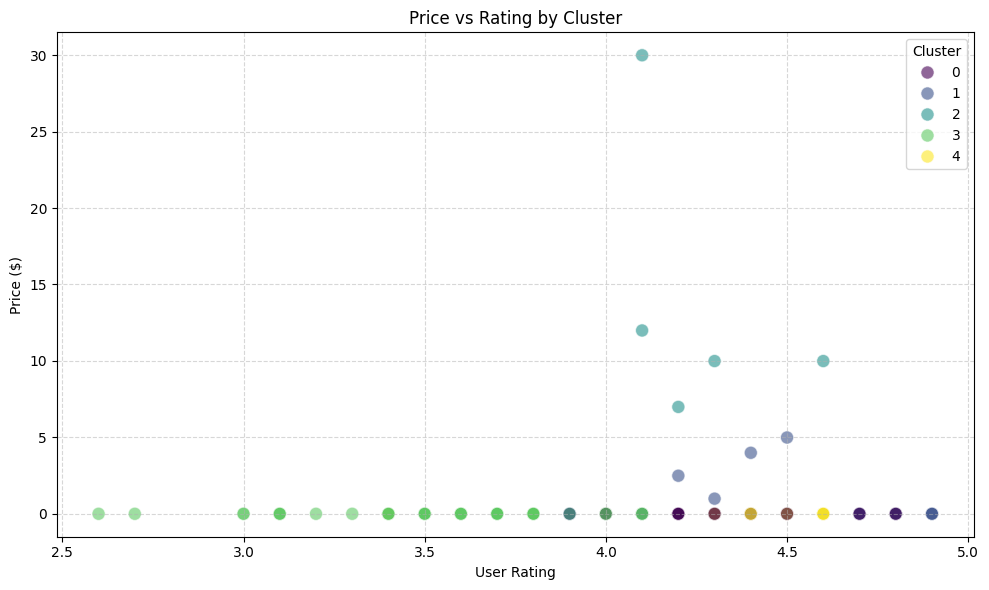

In [ ]:
# Scatter plot: price vs rating by cluster
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Rating',
    y='Price',
    hue='Cluster',
    palette='viridis',
    s=90,
    alpha=0.6
)

plt.title('Price vs Rating by Cluster')
plt.xlabel('User Rating')
plt.ylabel('Price ($)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Code Description**
Creates a scatter plot to analyze the relationship between app price and user rating across clusters.
**Output Description**
- Each point represents an app.
- Colors show different clusters.
- The chart helps compare pricing patterns and ratings among app groups.


**Cell 3: Analyze Cluster Characteristics (Profiling)**

In [ ]:
# Calculate the mean values for each feature within each cluster
cluster_profile = df.groupby('Cluster').agg({
    'Rating': 'mean',
    'Installs': 'mean',
    'Size': 'mean',
    'Price': 'mean',
    'Avg_Sentiment_Polarity': 'mean',
    'App': 'count'
}).rename(columns={'App': 'App_Count'})

print("Cluster Profiles (Mean values):")
display(cluster_profile)

Cluster Profiles (Mean values):


,Rating,Installs,Size,Price,Avg_Sentiment_Polarity,App_Count
Cluster,,,,,,
0,4.391273,6.394182e+07,14.785861,0.0000,0.199113,275
1,4.391786,9.702857e+05,15.502238,0.0445,0.310461,280
2,4.260000,4.220000e+04,27.580000,13.7900,0.199638,5
3,3.871084,2.869458e+06,16.865187,0.0000,0.086636,166
4,4.371111,3.847444e+07,70.444444,0.0000,0.072459,90


**Code Description**
Calculates the average values of important features for each cluster and counts the number of apps in each group.
**Output Description**
Displays a summary table for each cluster, including:
- average rating,
- average installs,
- average size,
- average price,
- average sentiment polarity,
- total number of apps.


# **Detailed Cluster Profiling & Analysis**

Based on the `cluster_profile` generated by the K-Means model, we have identified five distinct application segments within the Google Play Store ecosystem:

---

### **1. Cluster 0: "The Mainstream Success" (High-Volume Free Apps)**
* **Size:** 275 applications.
* **Key Metrics:** * Exceptionally high average installs (~**64 million**).
    * Strong average rating (**4.39**).
    * Compact footprint (**14.8 MB**) and completely **free ($0)**.
* **Persona:** This cluster represents successful, mainstream free applications. These are the "market giants" or essential utility tools that have achieved massive reach while maintaining high user stability.

---

### **2. Cluster 1: "High-Quality Gems" (User Favorites)**
* **Size:** 280 applications (The largest cluster).
* **Key Metrics:** * **Highest sentiment polarity (0.31)** across the dataset.
    * Moderate market reach (~**970,000** installs).
    * Optimized size (**15.5 MB**).
* **Persona:** These are the "hidden gems" of the store. While they haven't reached the blockbuster scale of Cluster 0, they boast the most satisfied and loyal user base, indicating a near-perfect product-market fit for their specific audience.

---

### **3. Cluster 2: "Premium & Specialized" (High-Value Niche)**
* **Size:** 5 applications (The smallest cluster - Outliers).
* **Key Metrics:** * Highest commercial value with an average price of **$13.79**.
    * Lowest install count (~**42,000**).
* **Persona:** This segment represents the Premium/Specialized niche. These apps target a very specific audience willing to pay a high entry price for specialized features, professional tools, or an ad-free premium experience.

---

### **4. Cluster 3: "The Underperformers" (High-Risk Segment)**
* **Size:** 166 applications.
* **Key Metrics:** * **Lowest average rating (3.87)**.
    * Near-zero sentiment polarity (**0.08**).
    * Decent install base (**2.8 million**).
* **Persona:** The "Danger Zone." Despite attracting a fair number of users, the significant negative feedback and stagnant sentiment suggest these apps suffer from technical issues (bugs), poor UX, or excessive advertising, requiring urgent quality intervention.

---

### **5. Cluster 4: "Heavyweight Performers" (Resource-Intensive Giants)**
* **Size:** 90 applications.
* **Key Metrics:** * **Largest average size (70.4 MB)**.
    * Massive market reach (>**38 million** installs).
    * Lowest sentiment polarity (**0.07**).
* **Persona:** This group consists of high-end mobile games or complex, feature-rich applications. While their high install counts show they are highly attractive, the low sentiment score indicates user frustration, likely due to hardware demands, battery consumption, or high performance expectations.

---

> **Strategic Conclusion:** This profiling provides a roadmap for targeted efforts: Focus on scaling **Cluster 1**, technical optimization for **Clusters 3 & 4**, and maintaining the dominant market position for **Cluster 0**.

**Cell 4: Visual Comparison of Key Metrics (Installs vs. Sentiment)**

**Purpose:** Visually compare the two most critical metrics (Installs and Sentiment) to quickly identify the market position of each cluster.

/tmp/ipykernel_2410/263481265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile.index, y='Installs', data=cluster_profile, ax=ax[0], palette='viridis')
/tmp/ipykernel_2410/263481265.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile.index, y='Avg_Sentiment_Polarity', data=cluster_profile, ax=ax[1], palette='magma')


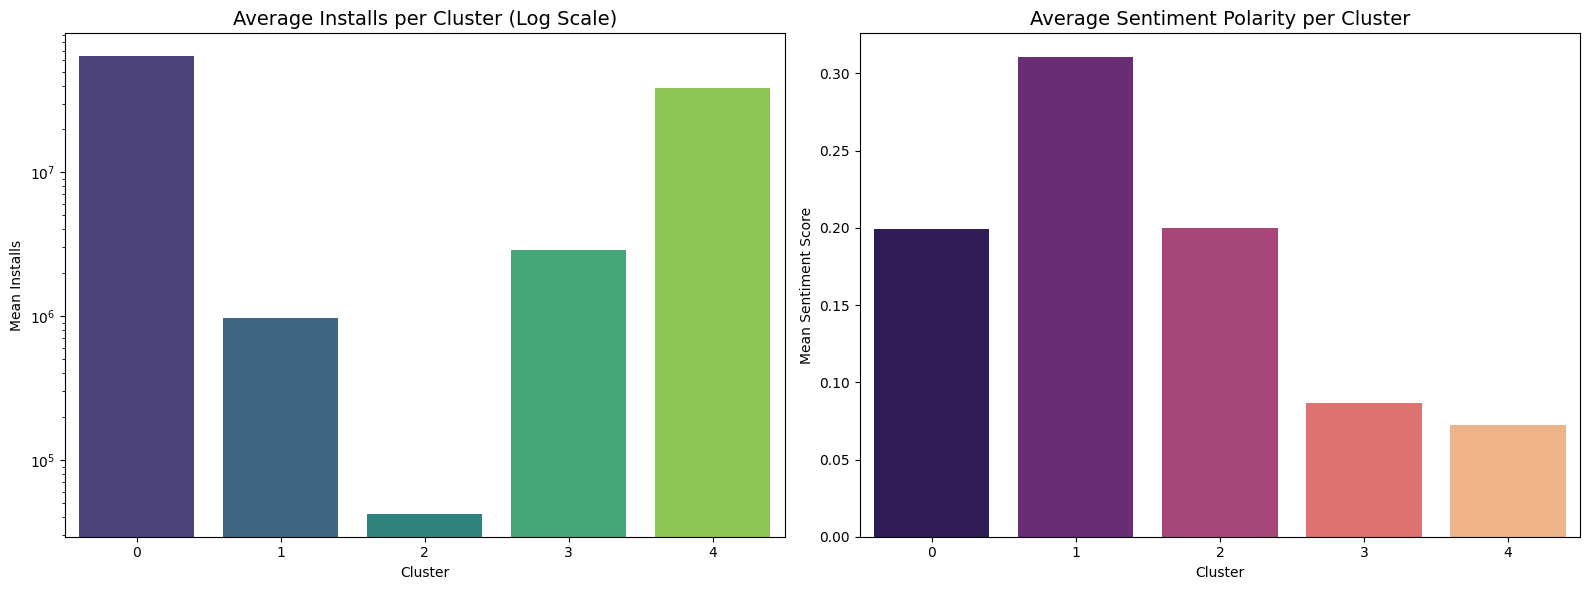

In [ ]:
# Create a figure with two side-by-side bar charts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Average Installs (Market Reach)
sns.barplot(x=cluster_profile.index, y='Installs', data=cluster_profile, ax=ax[0], palette='viridis')
ax[0].set_title('Average Installs per Cluster (Log Scale)', fontsize=14)
ax[0].set_yscale('log') # Handle massive variance in install counts
ax[0].set_ylabel('Mean Installs')
ax[0].set_xlabel('Cluster')

# Subplot 2: Average Sentiment (User Satisfaction)
sns.barplot(x=cluster_profile.index, y='Avg_Sentiment_Polarity', data=cluster_profile, ax=ax[1], palette='magma')
ax[1].set_title('Average Sentiment Polarity per Cluster', fontsize=14)
ax[1].set_ylabel('Mean Sentiment Score')
ax[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

**Code Description**
Creates two bar charts to compare clusters based on average installs and average sentiment polarity.
**Output Description**
- The first chart shows market reach using average installs.
- The second chart shows average user sentiment for each cluster.
- Helps identify which clusters are more popular and positively reviewed.


# **Strategic Analysis: Market Reach (Installs) vs. Perception Quality (Sentiment)**

---

### **Overview**
This analysis establishes the link between **"Quantity" (Installs)**—representing market scale—and **"Quality" (Sentiment)**—representing user satisfaction. A cluster with high installs but low sentiment indicates a "popular but polarizing" product that fails to fully satisfy its broad audience.

---

### **1. Clusters 0 & 4: The Giants**
* **Characteristics:** These two clusters boast the highest average installs, comfortably exceeding the $10^7$ threshold.
* **Insight:** Despite their scale, their Sentiment scores are either average (Cluster 0) or the lowest in the dataset (Cluster 4).
* **Analysis:** As apps reach a massive scale, maintaining absolute user satisfaction becomes increasingly difficult due to highly diverse user demographics and product complexity. For "Heavyweight" apps (Cluster 4), performance overhead and feature bloat often negatively impact sentiment.

---

### **2. Cluster 1: The Fan Favorites**
* **Characteristics:** Possesses moderate-to-high install volume but maintains an exceptionally high Sentiment score (above $0.30$).
* **Insight:** This is the market **"Sweet Spot."**
* **Analysis:** This group represents apps with superior User Experience (UX) that have built a strong emotional bond with their users. These apps have the highest potential for sustainable growth; with their quality already proven, they simply require a strategic "push" in marketing to scale.

---

### **3. Cluster 2: The Niche/Premium Segment**
* **Characteristics:** Lowest installation volume but maintains a very stable and positive Sentiment score.
* **Insight:** Value-driven over volume-driven.
* **Analysis:** Typically consists of paid or highly specialized apps. While the user base is small, it is highly loyal and satisfied with the core value proposition. The strategy here is retention and maximizing per-user value rather than mass-market expansion.

---

### **4. Cluster 3: The At-Risk Group**
* **Characteristics:** Decent install base but significantly lower Sentiment compared to Clusters 0, 1, and 2.
* **Insight:** **"The Red Zone."**
* **Analysis:** Users are downloading the app but are fundamentally dissatisfied with the experience. Without immediate intervention in product quality, this group faces a high **Churn Rate**, rendering marketing spend ineffective in the long run.

---

# **Strategic Summary**

Based on the interplay between "Quantity" and "Quality," the following actions are recommended:

* 🛠️ **Prioritize Improvement (Clusters 3 & 4):** Focus heavily on **Product & Development** to resolve friction points. Specifically for Cluster 4, where the user base is enormous, even a marginal increase in sentiment can lead to retaining millions of users who might otherwise churn.
* 🚀 **Prioritize Growth (Cluster 1):** The prime candidate for increased marketing spend. The product has reached "maturity" in terms of experience; the goal now is to scale reach to transform these into the next generation of "Super Apps."
* 💎 **Maintain Stability (Cluster 2):** Continue focusing on the loyal niche. Maintain service quality and niche authority rather than diluting the brand through broad, unfocused acquisition campaigns.

> **Key Takeaway:** Massive scale (Installs) does not always correlate with satisfaction (Sentiment). The key to market leadership is a two-step migration: first, move toward the characteristics of **Cluster 1** (Quality first), then scale toward **Cluster 0** (Quantity second).

---

**Cell 5: Top Representative Apps per Cluster**

**Purpose:** List specific apps within each cluster to validate the real-world logic of the clustering algorithm.

In [ ]:
print("=" * 60)
print("TOP APPS IN EACH CLUSTER")
print("=" * 60)

for cluster in sorted(df['Cluster'].unique()):

    print(f"\nCluster {cluster}")

    top_apps = (
        df[df['Cluster'] == cluster]
        .nlargest(5, 'Installs')[
            ['App', 'Category', 'Rating', 'Installs', 'Price']
        ]
    )

    display(top_apps)

TOP APPS IN EACH CLUSTER

Cluster 0


,App,Category,Rating,Installs,Price
61,Gmail,COMMUNICATION,4.3,1000000000,0.0
62,Hangouts,COMMUNICATION,4.0,1000000000,0.0
478,Facebook,SOCIAL,4.1,1000000000,0.0
481,Google+,SOCIAL,4.2,1000000000,0.0
518,Google Photos,PHOTOGRAPHY,4.5,1000000000,0.0



Cluster 1


,App,Category,Rating,Installs,Price
42,Google Primer,BUSINESS,4.4,10000000,0.0
250,Daily Workouts - Exercise Fitness Routine Trainer,HEALTH_AND_FITNESS,4.4,10000000,0.0
535,Cameringo Lite. Filters Camera,PHOTOGRAPHY,4.2,10000000,0.0
624,ASUS Sound Recorder,TOOLS,4.5,10000000,0.0
74,Calls & Text by Mo+,COMMUNICATION,4.2,5000000,0.0



Cluster 2


,App,Category,Rating,Installs,Price
370,Call of Duty:Black Ops Zombies,GAME,4.2,100000,6.99
445,Essential Anatomy 3,MEDICAL,4.1,50000,11.99
565,Golfshot Plus: Golf GPS,SPORTS,4.1,50000,29.99
694,BIG Launcher,PERSONALIZATION,4.3,10000,9.99
446,Diabetes & Diet Tracker,MEDICAL,4.6,1000,9.99



Cluster 3


,App,Category,Rating,Installs,Price
34,HTC Help,BOOKS_AND_REFERENCE,4.2,10000000,0.0
66,Cricket Visual Voicemail,COMMUNICATION,3.9,10000000,0.0
72,AT&T Visual Voicemail,COMMUNICATION,3.7,10000000,0.0
150,BBC Media Player,ENTERTAINMENT,3.4,10000000,0.0
159,Crunchyroll - Everything Anime,ENTERTAINMENT,3.7,10000000,0.0



Cluster 4


,App,Category,Rating,Installs,Price
318,Candy Crush Saga,GAME,4.4,500000000,0.0
707,Dropbox,PRODUCTIVITY,4.4,500000000,0.0
321,Clash Royale,GAME,4.6,100000000,0.0
324,Angry Birds Rio,GAME,4.4,100000000,0.0
325,Candy Crush Soda Saga,GAME,4.4,100000000,0.0


**Code Description**
Displays the top 5 apps with the highest installs in each cluster.
**Output Description**
For every cluster, a table is shown containing:
- app name,
- category,
- rating,
- number of installs,
- price.

This helps identify the most representative and popular apps in each cluster.


# **Strategic Analysis: App Listing by Cluster (Cell 5)**

The top apps by installation volume within each cluster validate the clustering algorithm's effectiveness by aligning with real-world market positions:

---

### **1. Cluster 0: Platform Blockbusters**
* **Sample Apps:** *Gmail, Facebook, Hangouts, Google Photos, Google+.*
* **Characteristics:** Essential services with massive installation bases (1 Billion+) and a price point of $0.0$. They dominate the **Communication** and **Social** categories.
* **Insight:** These are the established **"Market Giants"** that drive ecosystem growth and maintain absolute dominance in user reach.

---

### **2. Cluster 1: Quality Utilities**
* **Sample Apps:** *ASUS Sound Recorder, Google Primer, Daily Workouts, Cameringo Lite.*
* **Characteristics:** High-to-moderate installation volume (5M - 10M) with exceptional ratings (4.2 - 4.5). These apps focus on improving daily productivity and lifestyle.
* **Insight:** These represent the **"Hidden Gems"** where user experience is the top priority, resulting in high organic satisfaction.

---

### **3. Cluster 2: Premium & Specialized**
* **Sample Apps:** *Call of Duty: Black Ops Zombies, Essential Anatomy 3, Golfshot Plus.*
* **Characteristics:** High price points (ranging from $6.99 to $29.99) with significantly lower installation counts compared to free segments.
* **Insight:** This confirms a **Niche Market** strategy. Users are willing to pay a premium for high-value, specialized content in sectors like Gaming, Medical, and Professional Sports.

---

### **4. Cluster 3: At-Risk Apps (Underperformers)**
* **Sample Apps:** *BBC Media Player, Crunchyroll, AT&T Visual Voicemail.*
* **Characteristics:** Despite decent reach (10M+ installs), ratings are visibly lower (3.4 - 3.9).
* **Insight:** These apps serve as real-world evidence for the **"Underperformers"** segment. Many of these Entertainment and Communication services struggle to maintain user satisfaction, leading to poor retention signals.

---

### **5. Cluster 4: Heavyweight Performers**
* **Sample Apps:** *Candy Crush Saga, Dropbox, Clash Royale, Angry Birds Rio.*
* **Characteristics:** Massive reach (100M - 500M installs) with relatively high ratings (~4.4).
* **Insight:** This cluster consists of **Resource-Intensive** apps, such as high-end games or heavy productivity tools. While popular, they often face lower Sentiment scores (as analyzed in Cell 3) due to demanding hardware requirements and high performance expectations.

---

### **Summary of Clustering Logic**
The results from Cell 5 demonstrate that the algorithm successfully categorized applications based on their functional nature and market performance:
1.  **Market Presence:** Platform Blockbusters (Cluster 0).
2.  **User Experience:** Quality Utilities (Cluster 1).
3.  **Monetization:** Premium & Specialized (Cluster 2).
4.  **Quality Risk:** At-Risk Apps (Cluster 3).
5.  **Scale & Engagement:** Heavyweight Performers (Cluster 4).

**Cell 6: Multi-Dimensional Comparison (Radar Chart)**

**Purpose:** Use a radar chart to observe the "shape" of each cluster's multi-dimensional strengths on a unified scale.

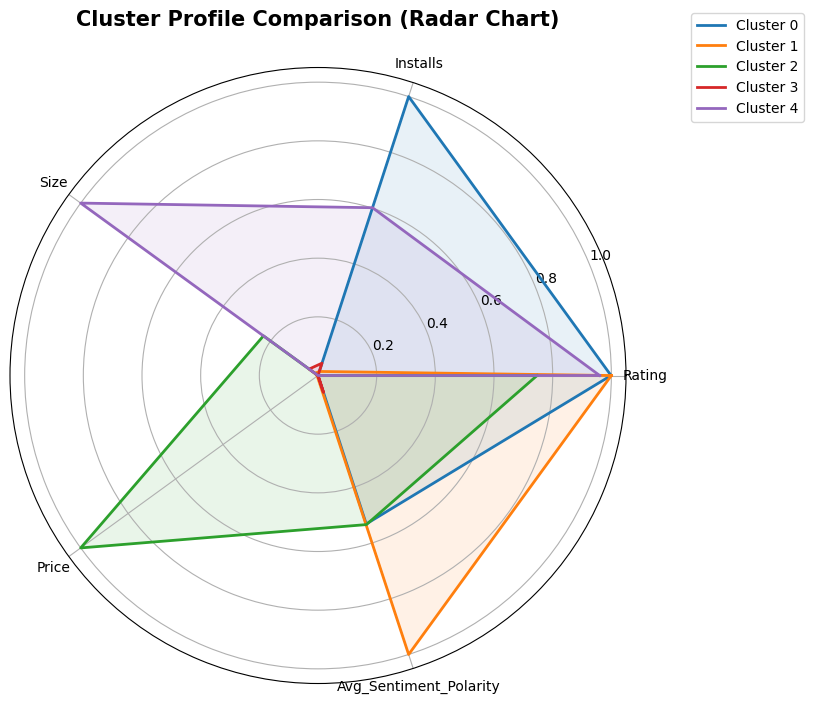

In [ ]:
# Normalize data (0-1) for consistent radar plotting
features_radar = ['Rating', 'Installs', 'Size', 'Price', 'Avg_Sentiment_Polarity']
cluster_norm = cluster_profile[features_radar].copy()

for col in features_radar:
    col_min, col_max = cluster_norm[col].min(), cluster_norm[col].max()
    if col_max != col_min:
        cluster_norm[col] = (cluster_norm[col] - col_min) / (col_max - col_min)
    else:
        cluster_norm[col] = 0.5

# Configure radar chart angles
angles = np.linspace(0, 2 * np.pi, len(features_radar), endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# SỬA DÒNG NÀY:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, row in cluster_norm.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, label=f'Cluster {i}', color=colors[i % len(colors)], linewidth=2)
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_thetagrids(np.degrees(angles[:-1]), features_radar)
ax.set_title('Cluster Profile Comparison (Radar Chart)', pad=30, fontsize=15, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# **Technical Analysis: Radar Chart Interpretation**

---

### **Overview**
* **Feature Axes:** The chart compares five critical variables standardized to a scale of $0$ to $1.0$: **Rating, Installs, Size, Price,** and **Avg_Sentiment_Polarity**.
* **Purpose:** To visualize the "surface area" and "competitive advantages" of each cluster. A cluster extending further toward a specific axis represents an absolute dominance in that feature relative to other groups.

---

### **Detailed Cluster Insights**

#### **1. Clusters 0 & 4: The Market Giants (Scalable Dominance)**
* **Characteristics:** Both clusters (represented by dark and light blue lines) reach the maximum threshold ($1.0$) on the **Rating** and **Installs** axes.
* **Key Differentiators:**
    * **Cluster 4:** Extends aggressively toward the **Size** axis, indicating resource-heavy applications (high-end games or system tools).
    * **Cluster 0:** Focuses on massive user reach while maintaining a more optimized application size.
* **Strategic Insight:** While these are market leaders in reach, their narrowed area on the **Sentiment** axis highlights the challenge of satisfying a massive, diverse user base.

#### **2. Cluster 1: The Fan Favorites (High-Sentiment Gems)**
* **Characteristics:** The orange boundary reaches the peak ($1.0$) on both **Avg_Sentiment_Polarity** and **Rating** axes.
* **Strategic Insight:** This represents the ideal segment for user experience. Although **Installs** are not as high as "The Giants," user satisfaction is absolute. This is the most sustainable model for apps aiming to build a loyal, long-term community.

#### **3. Cluster 2: The Premium Segment (High-Value Niche)**
* **Characteristics:** The green boundary extends to the maximum ($1.0$) on the **Price** axis.
* **Strategic Insight:** The chart confirms this as a paid/premium group. Their primary strength lies in high revenue per download, while scale (**Installs**) and **Sentiment** remain moderate to low.

#### **4. Cluster 3: The Underperformers (High-Risk Segment)**
* **Characteristics:** The red region is highly compressed, remaining closest to the chart's center.
* **Strategic Insight:** This group lacks competitive strength in any dimension. With critically low **Sentiment** and **Rating**, these apps require a total strategic overhaul or risk being phased out of the market.

---

### **Strategic Conclusion & Roadmap**

* **The "Funnel" Strategy:** A successful app journey should ideally begin with the profile of **Cluster 1** (Prioritize Sentiment & Rating). Once product-market fit is perfected, the goal is to expand the area toward the **Installs** axis to join **Cluster 0**.
* **Risk Warning:** If a cluster’s area begins to shrink toward the center (mimicking **Cluster 3**), stakeholders should halt marketing spend and pivot focus back to fixing core product flaws.
* **Resource Optimization:** **Cluster 4** developers must monitor the **Size** axis; excessive growth in file size acts as a barrier to higher **Sentiment** scores due to hardware demands and installation friction.

---

### Summary of Analysis & Visualization Steps

| Step | Action |
| :--- | :--- |
| *1* | *Data Loading:* Imported clustered datasets using robust error handling (try-except). |
| *2* | *Segmentation Mapping:* Visualized "Installs vs. Rating" to identify market clusters. |
| *3* | *Market Positioning:* Analyzed "Price vs. User Rating" to separate Free vs. Premium tiers. |
| *4* | *Cluster Profiling:* Aggregated mean values (Rating, Size, Price, Sentiment) for each group. |
| *5* | *Metric Comparison:* Created bar charts to compare Market Reach vs. User Satisfaction. |
| *6* | *Validation:* Identified top representative apps per cluster to verify real-world logic. |
| *7* | *Radar Analysis:* Normalized multi-dimensional data to compare cluster "shapes" on a unified scale. |

In [ ]:
df.groupby('Cluster')['Installs'].agg(['mean','median'])

,mean,median
Cluster,,
0,6.394182e+07,10000000.0
1,9.702857e+05,1000000.0
2,4.220000e+04,50000.0
3,2.869458e+06,1000000.0
4,3.847444e+07,10000000.0
